# Bootstrap versus Hessian comparison

This notebook pairs each `*_bootstrap_i.root` file with the corresponding
`*_results_i.root` file and produces only the requested comparisons:

1. amplitude magnitudes;
2. amplitude phases;
3. reconstructed experimental moments;
4. (R=sigma_L/sigma_T).

For bootstrap replicas, the central value is the arithmetic mean and the
uncertainty is the sample standard deviation.  For the Hessian result, the
central value and propagated uncertainty are read from the entry with the
absolute lowest finite `chi2` (or `log_val` if `chi2` is unavailable).  No
status filtering is applied to the Hessian minimum.

Every figure contains the direct comparison, the central-value difference

\[
\Delta x = x_{\mathrm{bootstrap}}-x_{\mathrm{Hessian}},
\]

and the uncertainty difference

\[
\Delta\sigma = \sigma_{\mathrm{bootstrap}}-\sigma_{\mathrm{Hessian}}.
\]


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import ROOT

try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)


# -------------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------------
BOOTSTRAP_DIR = Path(
    "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles"
).expanduser()
HESSIAN_DIR = BOOTSTRAP_DIR
OUTPUT_DIR = Path("outputs/bootstrap_vs_hessian_analysis")

BOOTSTRAP_TREE = "PartialWaves"
HESSIAN_TREE = "fitResults"

# Set this to a list of (bootstrap_path, hessian_path) pairs to override
# automatic discovery.
ROOT_FILE_PAIRS = None

# Failed bootstrap replicas are not part of the bootstrap distribution.
FILTER_BOOTSTRAP_VALID = True
BOOTSTRAP_DDOF = 1

# The user requested the ordinary arithmetic mean/std for phases.
# Phase central-value differences are wrapped to [-pi, pi] for readability.
WRAP_PHASE_DIFFERENCES = True

# H04_0_0 is fixed by the overall normalisation and is excluded, as in the
# earlier official-moment comparisons.
EXCLUDED_MOMENTS = {"RH04_0_0"}

mpl.rcParams["text.usetex"] = False
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 2.0,
    "axes.linewidth": 1.4,
    "savefig.dpi": 1200,
})

COLORS = {
    "bootstrap": "#0072B2",
    "hessian": "#D55E00",
    "value_difference": "#009E73",
    "error_difference": "#7A5195",
}

Q2_BY_PREFIX = {
    "ElRho": np.array([0.82, 1.19, 1.66, 3.06]),
    "MuRho": np.array([1.14, 1.60, 2.80, 6.02]),
    "ElOmega": np.array([1.28, 2.00, 4.00]),
    "MuOmega": np.array([1.16, 1.64, 3.58]),
    "ElPhi": np.array([1.20, 1.70, 4.50]),
}

FILE_RE = re.compile(
    r"(?P<prefix>(?:El|Mu)(?:Rho|Omega|Phi))_"
    r"(?P<method>bootstrap|results)_(?P<bin>\d+)$"
)
MAG_RE = re.compile(r"^[ab]_[TL]_\d+_(?:m?\d+)$")
PHASE_RE = re.compile(r"^[ab]phi_[TL]_\d+_(?:m?\d+)$")


In [2]:
# -------------------------------------------------------------------------
# ROOT reading, file matching and minimum selection
# -------------------------------------------------------------------------
def style_axis(ax, grid=False):
    ax.minorticks_on()
    ax.tick_params(which="major", direction="in", top=True, right=True,
                   length=7, width=1.2, pad=5)
    ax.tick_params(which="minor", direction="in", top=True, right=True,
                   length=3.5, width=0.9)
    if grid:
        ax.grid(True, color="0.90", linewidth=0.8, zorder=0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.3)


def save_figure(fig, path, show=True):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    print(f"Saved {path.resolve()}")


def list_root_branches(path, tree_name):
    path = Path(path).expanduser().resolve()
    root_file = ROOT.TFile.Open(str(path), "READ")
    if not root_file or root_file.IsZombie():
        raise OSError(f"Could not open ROOT file: {path}")
    try:
        tree = root_file.Get(tree_name)
        if not tree:
            raise KeyError(f"Tree {tree_name!r} not found in {path}")
        return [str(branch.GetName()) for branch in tree.GetListOfBranches()]
    finally:
        root_file.Close()


def read_root_columns(path, tree_name, columns):
    path = Path(path).expanduser().resolve()
    columns = list(dict.fromkeys(columns))
    rdf = ROOT.RDataFrame(tree_name, str(path))
    arrays = rdf.AsNumpy(columns=columns)
    return pd.DataFrame({name: np.asarray(values) for name, values in arrays.items()})


def discover_file_pairs(bootstrap_dir=BOOTSTRAP_DIR, hessian_dir=HESSIAN_DIR):
    bootstrap_dir = Path(bootstrap_dir).expanduser()
    hessian_dir = Path(hessian_dir).expanduser()
    pairs = []
    for bootstrap_path in sorted(bootstrap_dir.glob("*_bootstrap_*.root")):
        match = FILE_RE.match(bootstrap_path.stem)
        if not match:
            continue
        prefix = match.group("prefix")
        bin_index = int(match.group("bin"))
        hessian_path = hessian_dir / f"{prefix}_results_{bin_index}.root"
        if hessian_path.exists():
            pairs.append((bootstrap_path.resolve(), hessian_path.resolve()))
        else:
            warnings.warn(f"No Hessian partner found for {bootstrap_path.name}")
    return pairs


def pair_metadata(bootstrap_path, hessian_path):
    bootstrap_match = FILE_RE.match(Path(bootstrap_path).stem)
    hessian_match = FILE_RE.match(Path(hessian_path).stem)
    if not bootstrap_match or not hessian_match:
        raise ValueError(f"Unrecognised pair: {bootstrap_path}, {hessian_path}")
    prefix = bootstrap_match.group("prefix")
    bin_index = int(bootstrap_match.group("bin"))
    if prefix != hessian_match.group("prefix") or bin_index != int(hessian_match.group("bin")):
        raise ValueError(f"Mismatched ROOT files: {bootstrap_path}, {hessian_path}")

    beam = r"e^-" if prefix.startswith("El") else r"\mu^-"
    if prefix.endswith("Rho"):
        particle = r"\rho^0"
    elif prefix.endswith("Omega"):
        particle = r"\omega"
    else:
        particle = r"\phi"

    q2_values = Q2_BY_PREFIX.get(prefix)
    q2 = float(q2_values[bin_index]) if q2_values is not None and bin_index < len(q2_values) else np.nan
    title = rf"${beam}{particle}$, bin {bin_index}"
    if np.isfinite(q2):
        title += rf", $\langle Q^2\rangle={q2:g}\,\mathrm{{GeV}}^2$"
    return {
        "prefix": prefix,
        "bin": bin_index,
        "q2": q2,
        "key": f"{prefix}_{bin_index}",
        "title": title,
    }


def bootstrap_quality_mask(frame):
    mask = np.ones(len(frame), dtype=bool)
    if FILTER_BOOTSTRAP_VALID and "valid" in frame:
        mask &= frame["valid"].astype(bool).to_numpy()
    if FILTER_BOOTSTRAP_VALID and "status" in frame:
        mask &= frame["status"].to_numpy() == 0
    for objective in ("chi2", "log_val", "log10_chi2"):
        if objective in frame:
            mask &= np.isfinite(pd.to_numeric(frame[objective], errors="coerce"))
            break
    return mask


def select_absolute_lowest(frame):
    objective = next((name for name in ("chi2", "log_val", "val") if name in frame), None)
    if objective is None:
        raise KeyError("No chi2, log_val, or val branch in Hessian result")
    values = pd.to_numeric(frame[objective], errors="coerce").to_numpy(dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        raise RuntimeError(f"No finite {objective} values")
    index = int(np.argmin(np.where(finite, values, np.inf)))
    return index, frame.iloc[index].copy(), objective


def hessian_error_branch(value_branch, available_columns):
    available = set(available_columns)
    candidates = [
        f"err__{value_branch}",
        f"{value_branch}_err",
        f"{value_branch}err",
        f"err_{value_branch}",
        f"error__{value_branch}",
    ]

    # Also support the reflerr naming convention, e.g.
    # a_T_1_1 -> aerr_T_1_1 and aphi_T_1_1 -> aphierr_T_1_1.
    if MAG_RE.match(value_branch):
        candidates.extend([
            value_branch[0] + "err" + value_branch[1:],
            value_branch[0] + "err" + value_branch[1:] + "_",
        ])
    elif PHASE_RE.match(value_branch):
        reflection = value_branch[0]
        remainder = value_branch[len(reflection + "phi"):]
        candidates.extend([
            reflection + "phierr" + remainder,
            reflection + "phierr" + remainder + "_",
            reflection + "errphi" + remainder,
        ])

    return next((candidate for candidate in candidates if candidate in available), None)


if ROOT_FILE_PAIRS is None:
    ROOT_FILE_PAIRS = discover_file_pairs()
else:
    ROOT_FILE_PAIRS = [
        (Path(bootstrap).expanduser().resolve(), Path(hessian).expanduser().resolve())
        for bootstrap, hessian in ROOT_FILE_PAIRS
    ]

if not ROOT_FILE_PAIRS:
    raise FileNotFoundError(
        "No matching *_bootstrap_i.root and *_results_i.root pairs were found"
    )

pair_index = pd.DataFrame([
    {
        **pair_metadata(bootstrap, hessian),
        "bootstrap_file": str(bootstrap),
        "hessian_file": str(hessian),
    }
    for bootstrap, hessian in ROOT_FILE_PAIRS
]).sort_values(["prefix", "bin"]).reset_index(drop=True)

display(pair_index[["prefix", "bin", "q2", "bootstrap_file", "hessian_file"]])


,prefix,bin,q2,bootstrap_file,hessian_file
0,ElOmega,0,1.28,/home/dleahy27/Desktop/PhD/Electroproduction/E...,/home/dleahy27/Desktop/PhD/Electroproduction/E...
1,ElOmega,1,2.00,/home/dleahy27/Desktop/PhD/Electroproduction/E...,/home/dleahy27/Desktop/PhD/Electroproduction/E...
2,ElOmega,2,4.00,/home/dleahy27/Desktop/PhD/Electroproduction/E...,/home/dleahy27/Desktop/PhD/Electroproduction/E...
3,ElPhi,0,1.20,/home/dleahy27/Desktop/PhD/Electroproduction/E...,/home/dleahy27/Desktop/PhD/Electroproduction/E...
4,ElPhi,1,1.70,/home/dleahy27/Desktop/PhD/Electroproduction/E...,/home/dleahy27/Desktop/PhD/Electroproduction/E...
5,ElPhi,2,4.50,/home/dleahy27/Desktop/PhD/Electroproduction/E...,/home/dleahy27/Desktop/PhD/Electroproduction/E...
6,ElRho,0,0.82,/home/dleahy27/Desktop/PhD/Electroproduction/E...,/home/dleahy27/Desktop/PhD/Electroproduction/E...
7,ElRho,1,1.19,/home/dleahy27/Desktop/PhD/Electroproduction/E...,/home/dleahy27/Desktop/PhD/Electroproduction/E...
8,ElRho,2,1.66,/home/dleahy27/Desktop/PhD/Electroproduction/E...,/home/dleahy27/Desktop/PhD/Electroproduction/E...
9,ElRho,3,3.06,/home/dleahy27/Desktop/PhD/Electroproduction/E...,/home/dleahy27/Desktop/PhD/Electroproduction/E...


In [3]:
# -------------------------------------------------------------------------
# Summary construction and the four requested comparison plots
# -------------------------------------------------------------------------
def finite_sample(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]


def bootstrap_mean_std(values):
    values = finite_sample(values)
    if len(values) == 0:
        return np.nan, np.nan
    error = np.std(values, ddof=BOOTSTRAP_DDOF) if len(values) > BOOTSTRAP_DDOF else np.nan
    return float(np.mean(values)), float(error)


def wrap_phase(angle):
    return (angle + np.pi) % (2.0 * np.pi) - np.pi


def wave_label(branch):
    match = re.match(r"(?P<refl>[ab])_(?P<pol>[TL])_(?P<ell>\d+)_(?P<m>m?\d+)", branch)
    if not match:
        return branch.replace("_", r"\_")
    info = match.groupdict()
    reflection = "+" if info["refl"] == "a" else "-"
    wave = {"0": "S", "1": "P"}.get(info["ell"], rf"\ell={info['ell']}")
    m = info["m"].replace("m", "-")
    return "$%s^{%s}_{\\mathrm{%s}%s}$" % (wave, reflection, info["pol"], m)


def phase_label(branch):
    magnitude_branch = branch[0] + branch[len(branch[0] + "phi"):]
    return rf"$\varphi\!\left({wave_label(magnitude_branch).strip('$')}\right)$"


def moment_label(branch):
    if branch.startswith("RH04_"):
        _, L, M = branch.split("_")
        return rf"$\widetilde{{H}}^{{04}}_{{{L}{M}}}$"
    match = re.match(r"RH_(?P<alpha>\d+)_(?P<L>\d+)_(?P<M>m?\d+)$", branch)
    if match:
        info = match.groupdict()
        M = info["M"].replace("m", "-")
        return rf"$H^{{{info['alpha']}}}_{{{info['L']}{M}}}$"
    return branch.replace("_", r"\_")


def make_comparison_figure(table, labels, ylabel, title, output_path,
                           wrap_value_difference=False, x_values=None,
                           x_label=None):
    if table.empty:
        return

    if x_values is None:
        x = np.arange(len(table), dtype=float)
        categorical = True
    else:
        x = np.asarray(x_values, dtype=float)
        categorical = False

    bootstrap_value = table["bootstrap_value"].to_numpy(dtype=float)
    bootstrap_error = table["bootstrap_error"].to_numpy(dtype=float)
    hessian_value = table["hessian_value"].to_numpy(dtype=float)
    hessian_error = table["hessian_error"].to_numpy(dtype=float)

    value_difference = bootstrap_value - hessian_value
    if wrap_value_difference:
        value_difference = wrap_phase(value_difference)
    error_difference = bootstrap_error - hessian_error

    width = max(10.5, 0.58 * len(table)) if categorical else 9.0
    fig, axes = plt.subplots(
        3, 1, figsize=(width, 9.0), sharex=True, layout="constrained",
        gridspec_kw={"height_ratios": [3.1, 1.35, 1.35]},
    )

    if categorical:
        offset = 0.10
    else:
        span = np.ptp(x) if len(x) > 1 else 1.0
        offset = 0.012 * max(span, 1.0)

    axes[0].errorbar(
        x - offset, bootstrap_value, yerr=bootstrap_error,
        fmt="o", markersize=7.5, capsize=3.5, elinewidth=1.8,
        color=COLORS["bootstrap"], label=r"Bootstrap mean $\pm$ standard deviation",
    )
    axes[0].errorbar(
        x + offset, hessian_value, yerr=hessian_error,
        fmt="s", markersize=7.0, capsize=3.5, elinewidth=1.8,
        color=COLORS["hessian"], label=r"Minimum-$\chi^2$ value $\pm$ Hessian error",
    )
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(title)
    axes[0].legend(frameon=False, ncol=2)

    axes[1].plot(x, value_difference, "o", markersize=6.5,
                 color=COLORS["value_difference"])
    axes[1].axhline(0.0, color="0.35", linestyle="--", linewidth=1.2)
    axes[1].set_ylabel(r"$x_{\rm boot}-x_{\rm Hess}$")

    axes[2].plot(x, error_difference, "s", markersize=6.0,
                 color=COLORS["error_difference"])
    axes[2].axhline(0.0, color="0.35", linestyle="--", linewidth=1.2)
    axes[2].set_ylabel(r"$\sigma_{\rm boot}-\sigma_{\rm Hess}$")

    if categorical:
        axes[2].set_xticks(x, labels, rotation=50, ha="right")
        axes[2].set_xlabel(x_label or "Quantity")
    else:
        axes[2].set_xlabel(x_label or r"$Q^2\ [\mathrm{GeV}^2]$")
        axes[2].xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:g}"))

    for ax in axes:
        style_axis(ax, grid=True)

    fig.align_ylabels(axes)
    save_figure(fig, output_path)


def build_parameter_table(bootstrap, hessian_best, branches, hessian_columns):
    rows = []
    for branch in branches:
        error_branch = hessian_error_branch(branch, hessian_columns)
        if error_branch is None or branch not in hessian_best.index:
            warnings.warn(f"No Hessian uncertainty branch found for {branch}; skipping")
            continue
        bootstrap_value, bootstrap_error = bootstrap_mean_std(bootstrap[branch])
        rows.append({
            "quantity": branch,
            "bootstrap_value": bootstrap_value,
            "bootstrap_error": bootstrap_error,
            "hessian_value": float(hessian_best[branch]),
            "hessian_error": abs(float(hessian_best[error_branch])),
            "hessian_error_branch": error_branch,
        })
    return pd.DataFrame(rows)


def build_moment_table(bootstrap, hessian_best, bootstrap_columns, hessian_columns):
    rows = []
    for bootstrap_branch in sorted(
        (name for name in bootstrap_columns if name.startswith("fit_RH")),
        key=lambda name: [int(value) if value.isdigit() else value
                          for value in re.split(r"(\d+)", name)],
    ):
        hessian_branch = bootstrap_branch[len("fit_"):]
        if hessian_branch in EXCLUDED_MOMENTS or hessian_branch not in hessian_columns:
            continue
        error_branch = hessian_error_branch(hessian_branch, hessian_columns)
        if error_branch is None:
            warnings.warn(f"No Hessian uncertainty branch found for {hessian_branch}; skipping")
            continue
        bootstrap_value, bootstrap_error = bootstrap_mean_std(bootstrap[bootstrap_branch])
        rows.append({
            "quantity": hessian_branch,
            "bootstrap_branch": bootstrap_branch,
            "hessian_branch": hessian_branch,
            "bootstrap_value": bootstrap_value,
            "bootstrap_error": bootstrap_error,
            "hessian_value": float(hessian_best[hessian_branch]),
            "hessian_error": abs(float(hessian_best[error_branch])),
            "hessian_error_branch": error_branch,
        })
    return pd.DataFrame(rows)


def hessian_R(best, hessian_columns):
    error_branch = hessian_error_branch("R", hessian_columns)
    if "R" in best.index and error_branch is not None:
        return float(best["R"]), abs(float(best[error_branch]))

    required = ["H_4_0_0", "H_0_0_0"]
    if not all(name in best.index for name in required):
        raise KeyError("Hessian result has neither R nor H_4_0_0/H_0_0_0")
    error4 = hessian_error_branch("H_4_0_0", hessian_columns)
    error0 = hessian_error_branch("H_0_0_0", hessian_columns)
    if error4 is None or error0 is None:
        raise KeyError("No Hessian error branches are available for R propagation")
    h4 = float(best["H_4_0_0"])
    h0 = float(best["H_0_0_0"])
    if abs(h0) <= 1e-15:
        raise ZeroDivisionError("H_0_0_0 is zero at the Hessian minimum")
    value = h4 / h0
    # Compatibility fallback only: this omits Cov(H4,H0). New files should
    # provide the dedicated covariance-propagated err__R branch.
    error = np.hypot(float(best[error4]) / h0,
                     h4 * float(best[error0]) / h0**2)
    warnings.warn("Using diagonal-only Hessian propagation for R")
    return value, error


def bootstrap_R(bootstrap):
    if "R" in bootstrap:
        values = bootstrap["R"].to_numpy(dtype=float)
    elif "H_4_0_0" in bootstrap and "H_0_0_0" in bootstrap:
        numerator = bootstrap["H_4_0_0"].to_numpy(dtype=float)
        denominator = bootstrap["H_0_0_0"].to_numpy(dtype=float)
        valid = np.isfinite(numerator) & np.isfinite(denominator) & (np.abs(denominator) > 1e-15)
        values = numerator[valid] / denominator[valid]
    else:
        raise KeyError("Bootstrap file has neither R nor H_4_0_0/H_0_0_0")
    return bootstrap_mean_std(values)


ElOmega_0: bootstrap 944/1000 replicas; Hessian entry 36181/100000, chi2=8.81024097564


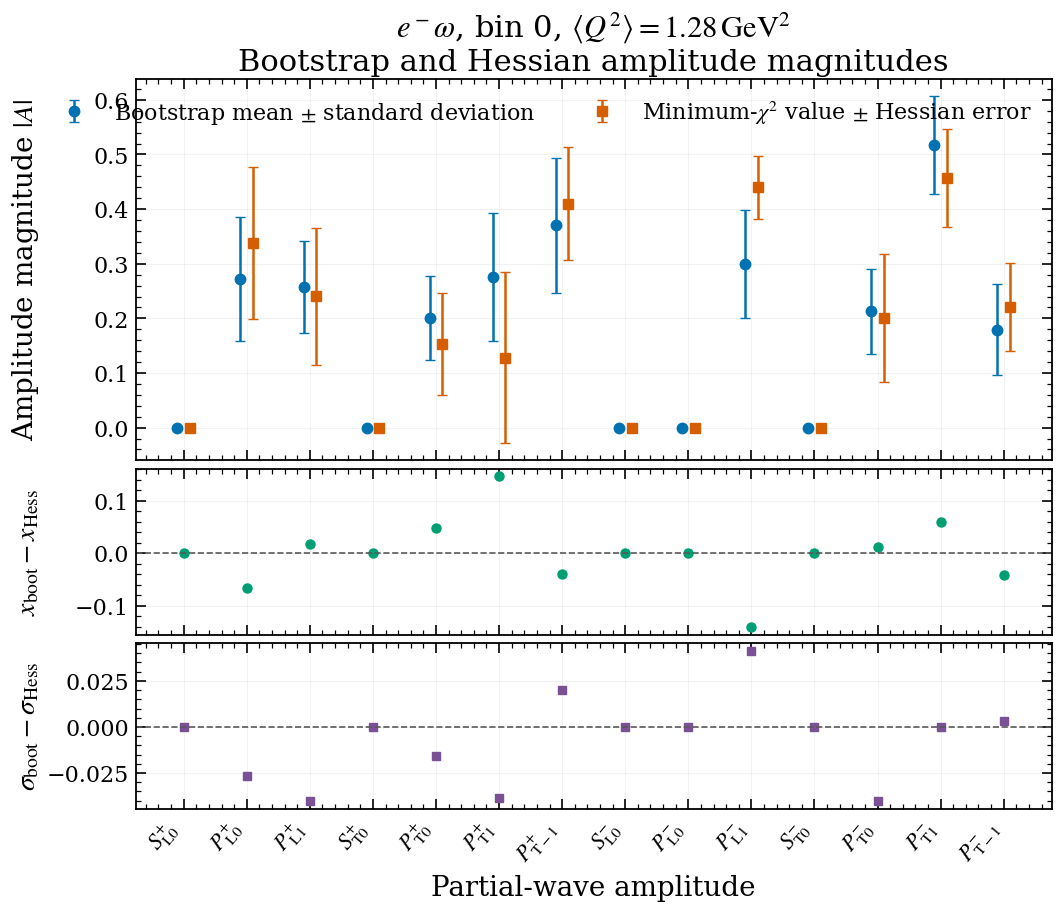

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElOmega_0/ElOmega_0_bootstrap_vs_hessian_amplitudes.png


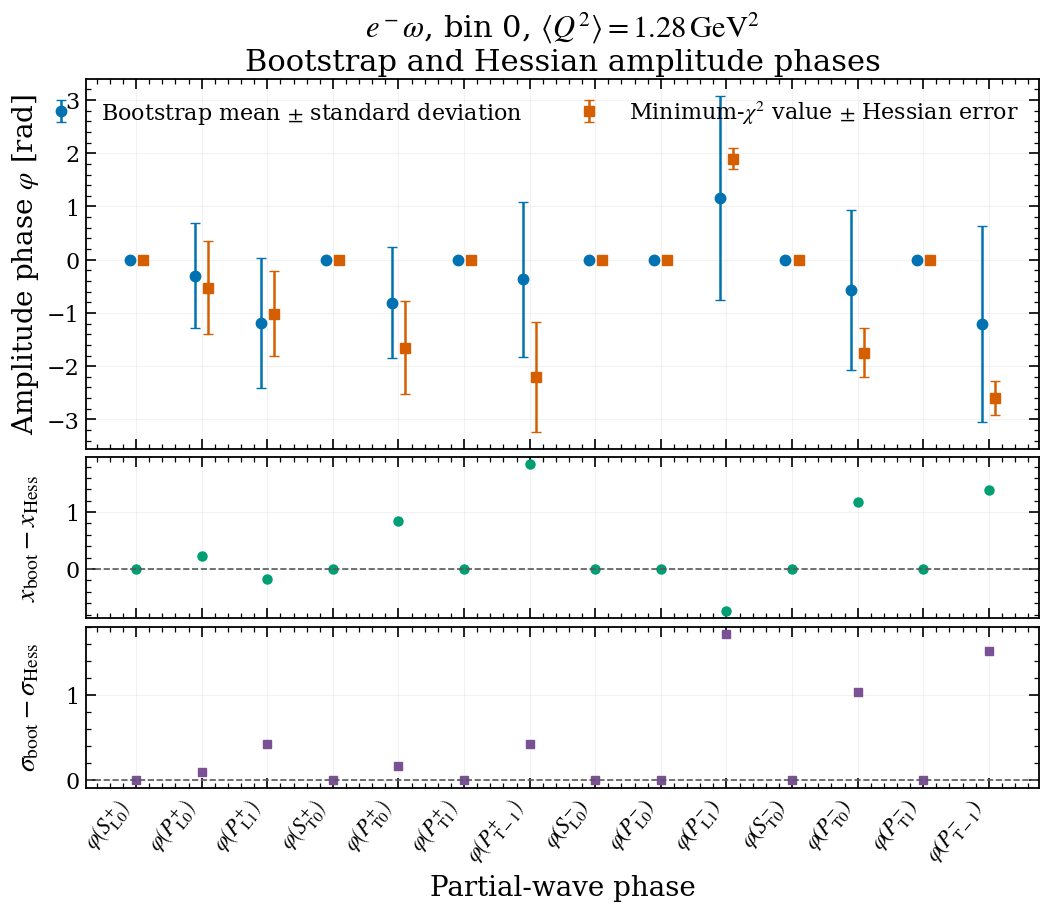

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElOmega_0/ElOmega_0_bootstrap_vs_hessian_phases.png


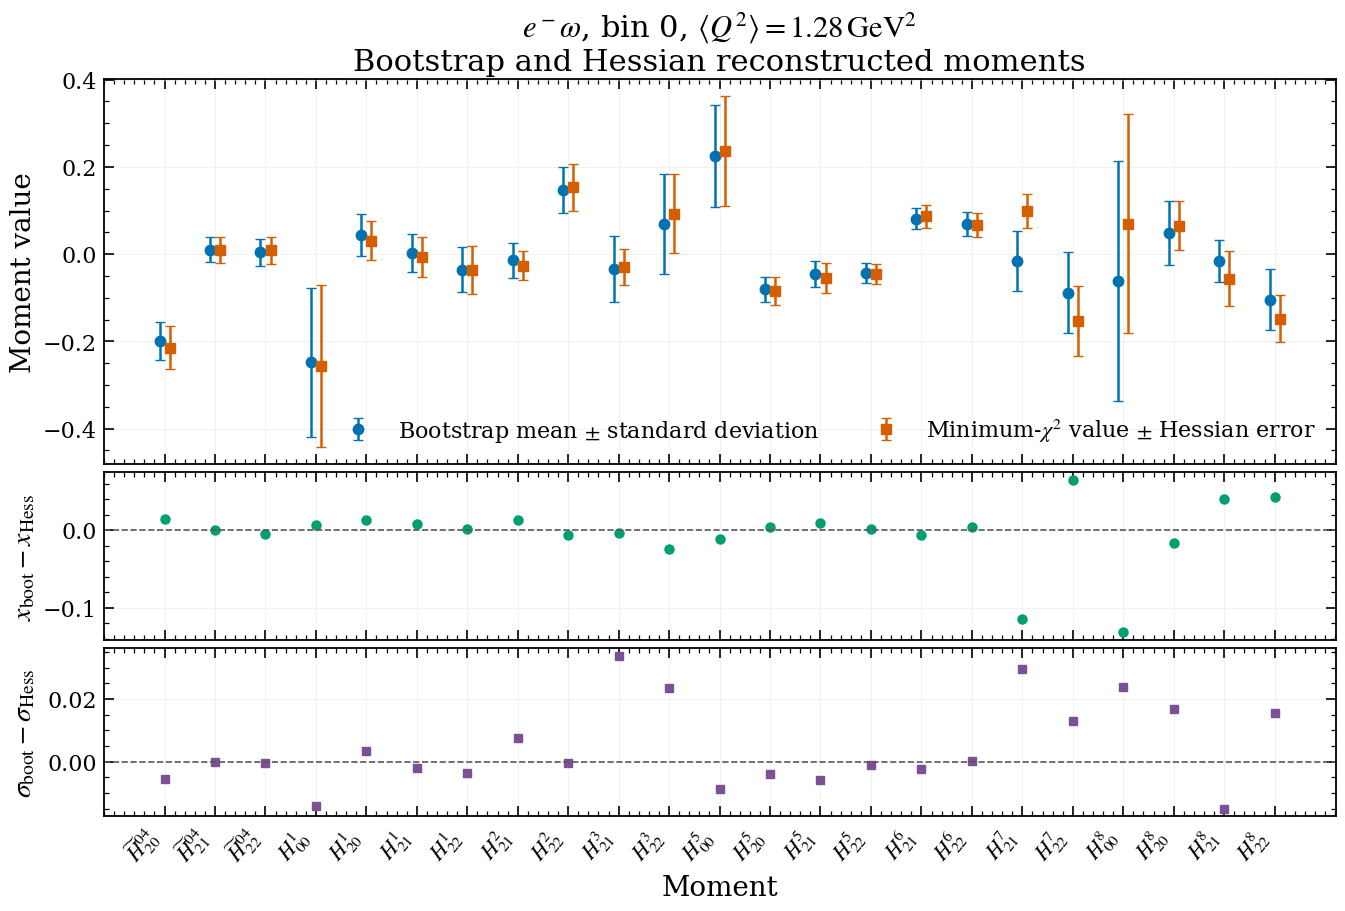

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElOmega_0/ElOmega_0_bootstrap_vs_hessian_moments.png
ElOmega_1: bootstrap 965/1000 replicas; Hessian entry 80722/100000, chi2=3.12423253493


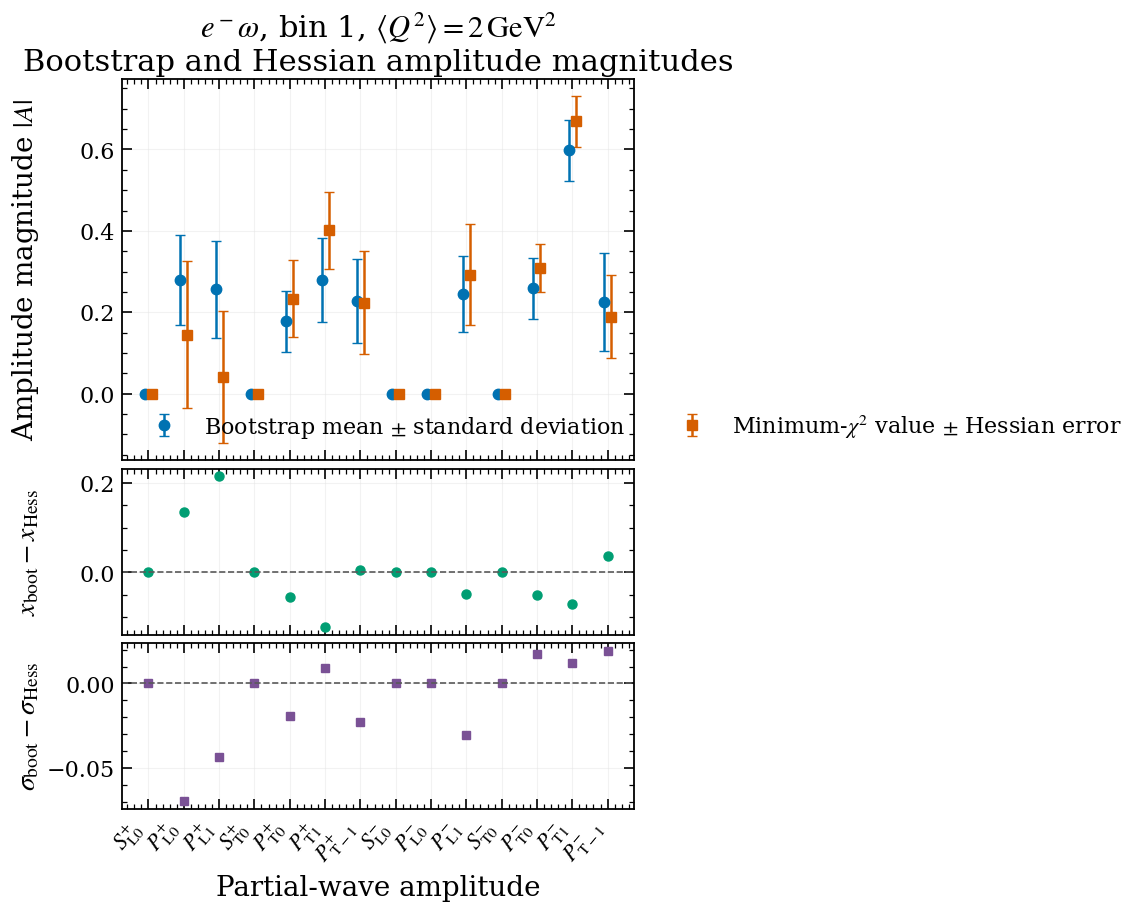

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElOmega_1/ElOmega_1_bootstrap_vs_hessian_amplitudes.png


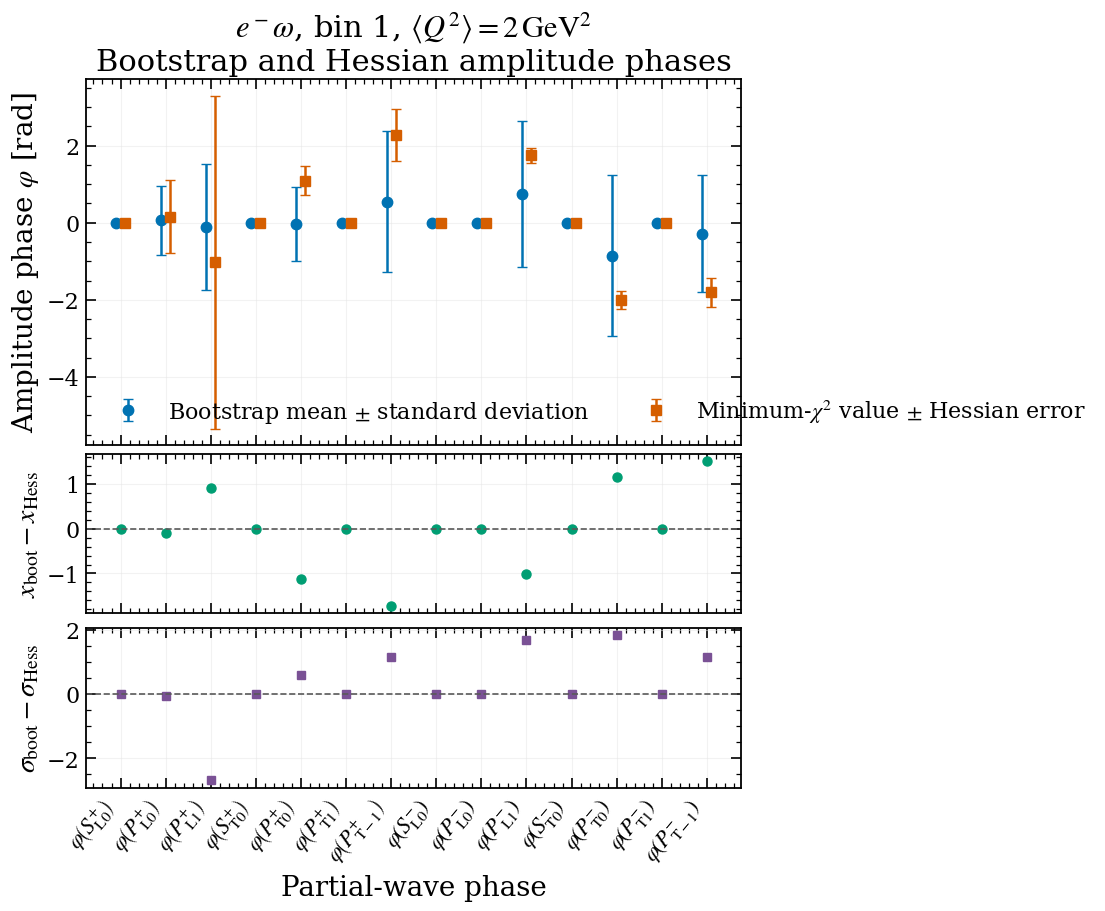

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElOmega_1/ElOmega_1_bootstrap_vs_hessian_phases.png


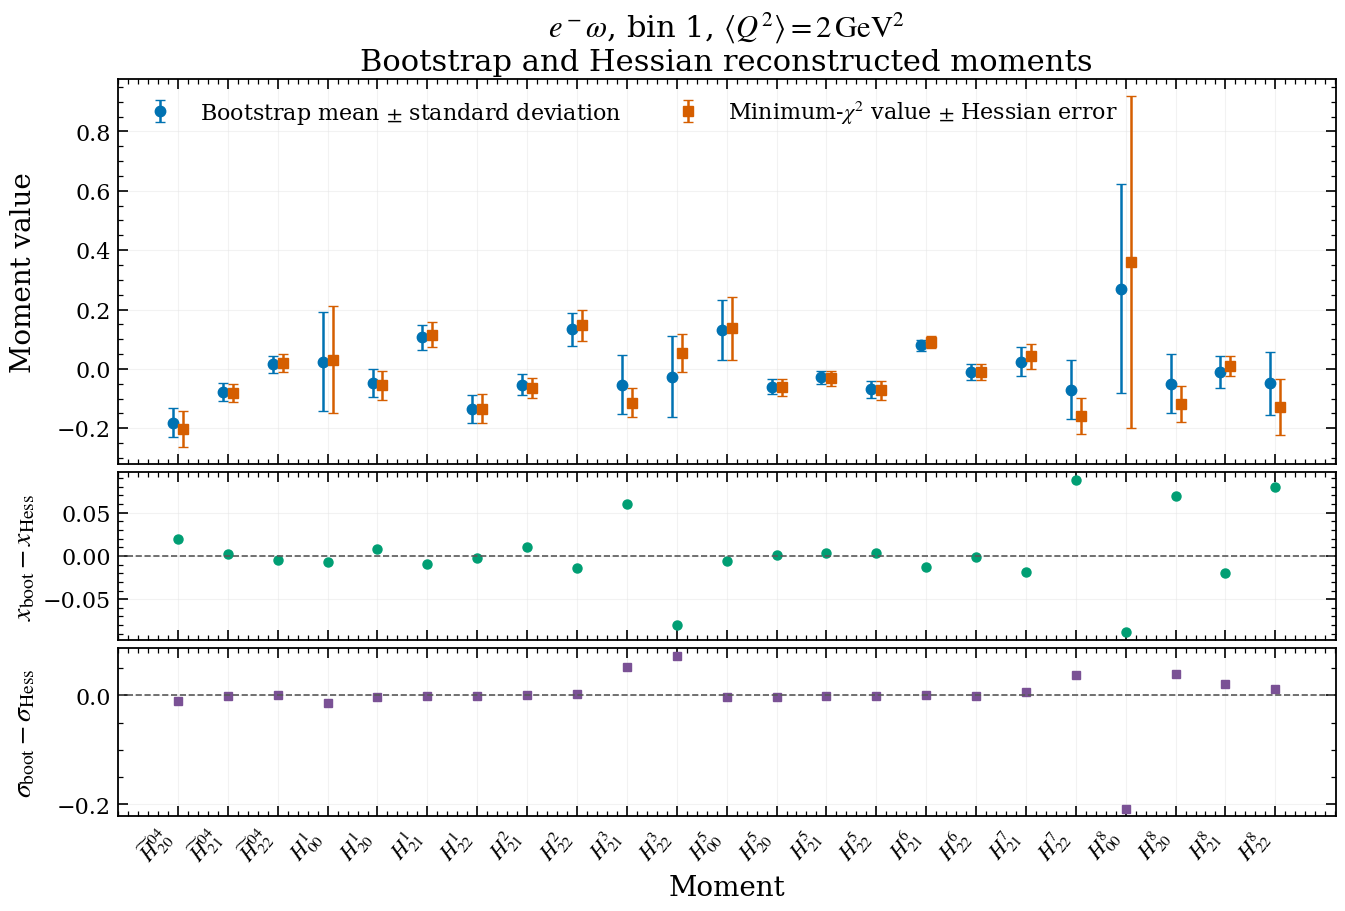

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElOmega_1/ElOmega_1_bootstrap_vs_hessian_moments.png
ElOmega_2: bootstrap 902/1000 replicas; Hessian entry 16963/100000, chi2=12.7290167483


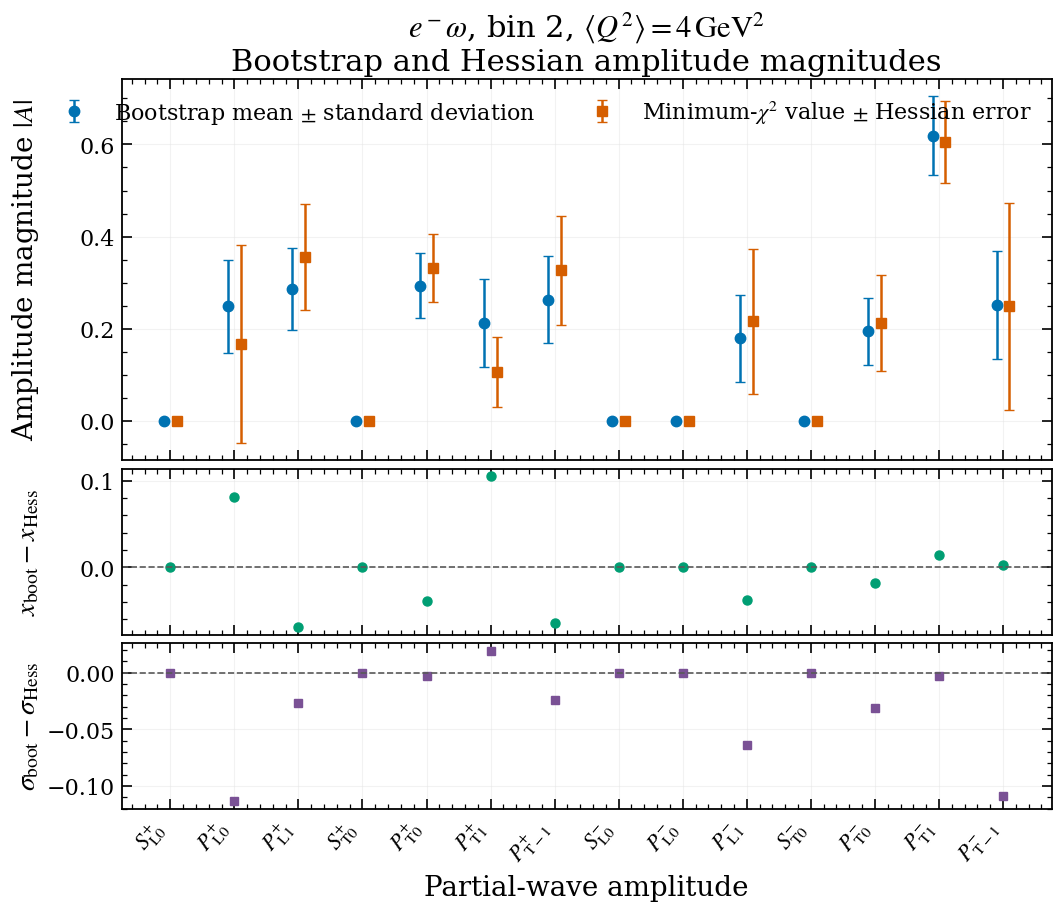

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElOmega_2/ElOmega_2_bootstrap_vs_hessian_amplitudes.png


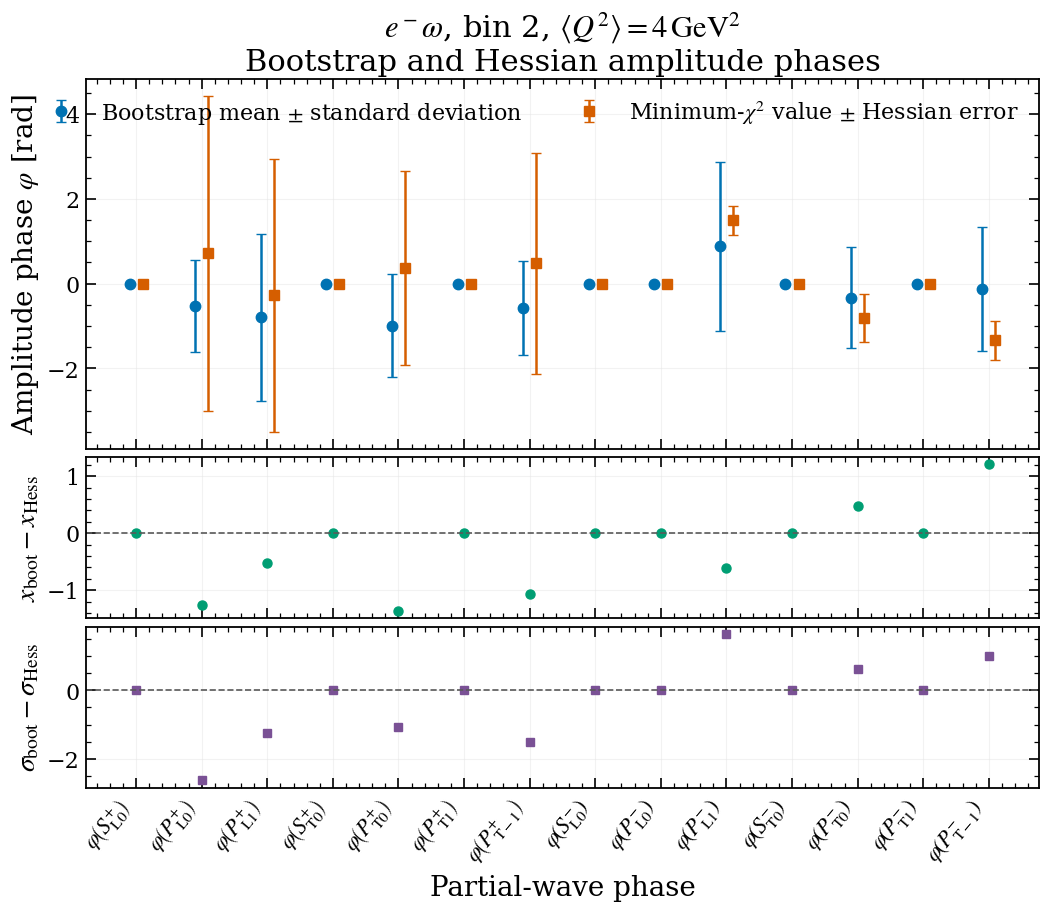

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElOmega_2/ElOmega_2_bootstrap_vs_hessian_phases.png


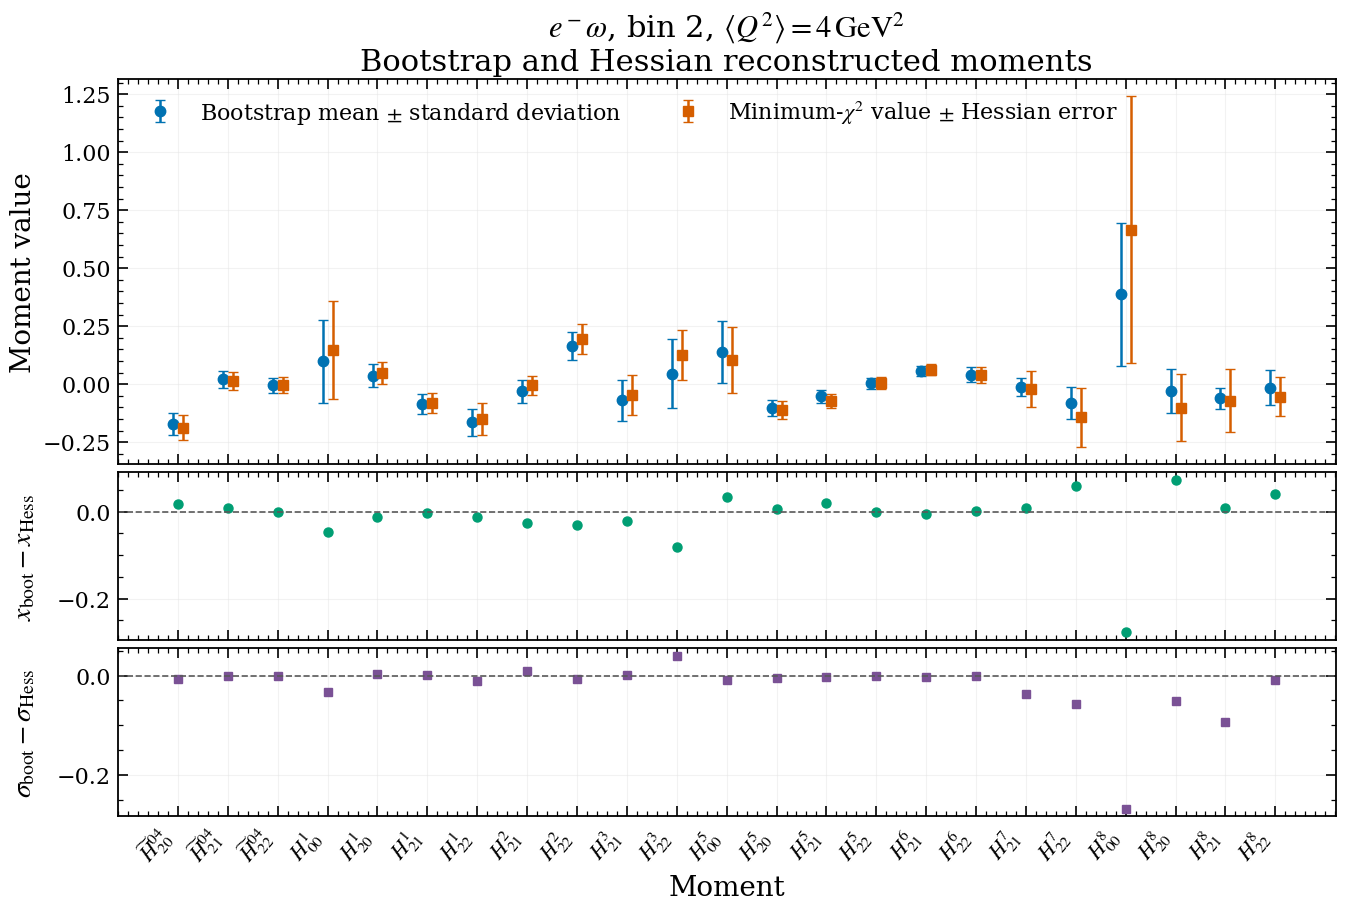

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElOmega_2/ElOmega_2_bootstrap_vs_hessian_moments.png
ElPhi_0: bootstrap 996/1000 replicas; Hessian entry 2327/100000, chi2=6.89814355458


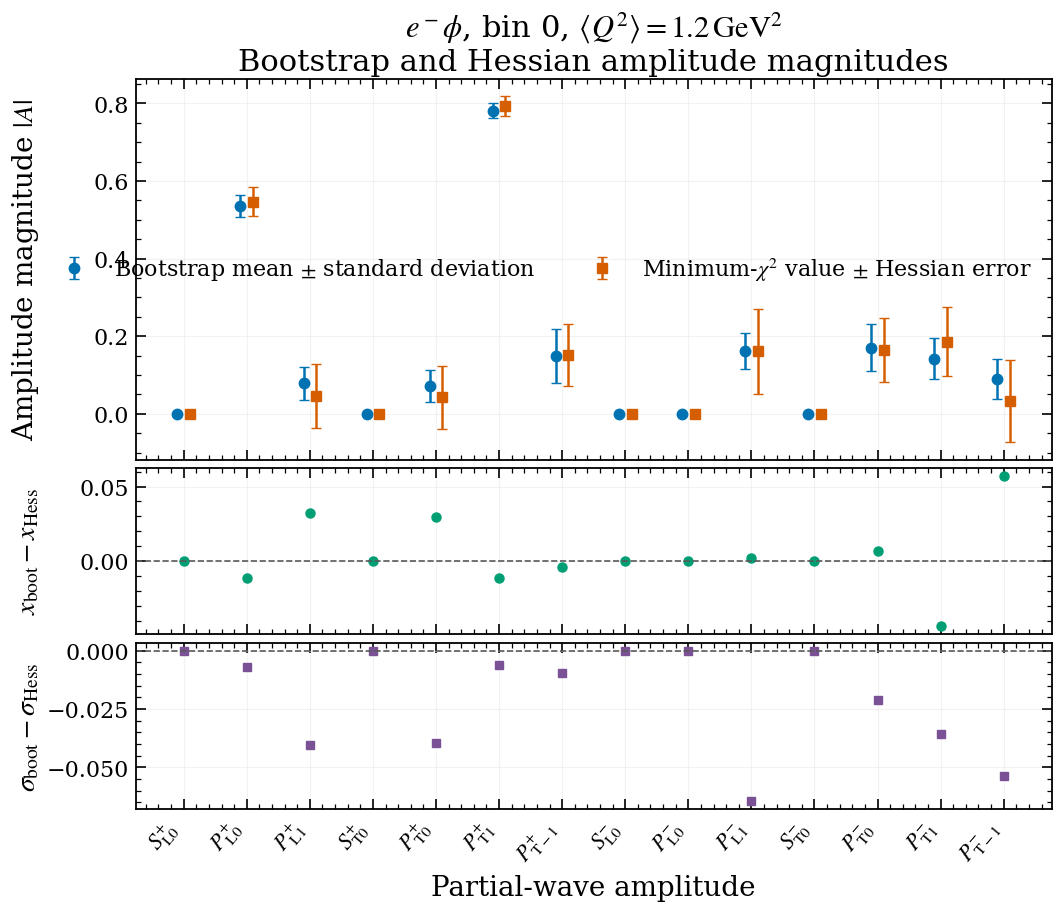

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElPhi_0/ElPhi_0_bootstrap_vs_hessian_amplitudes.png


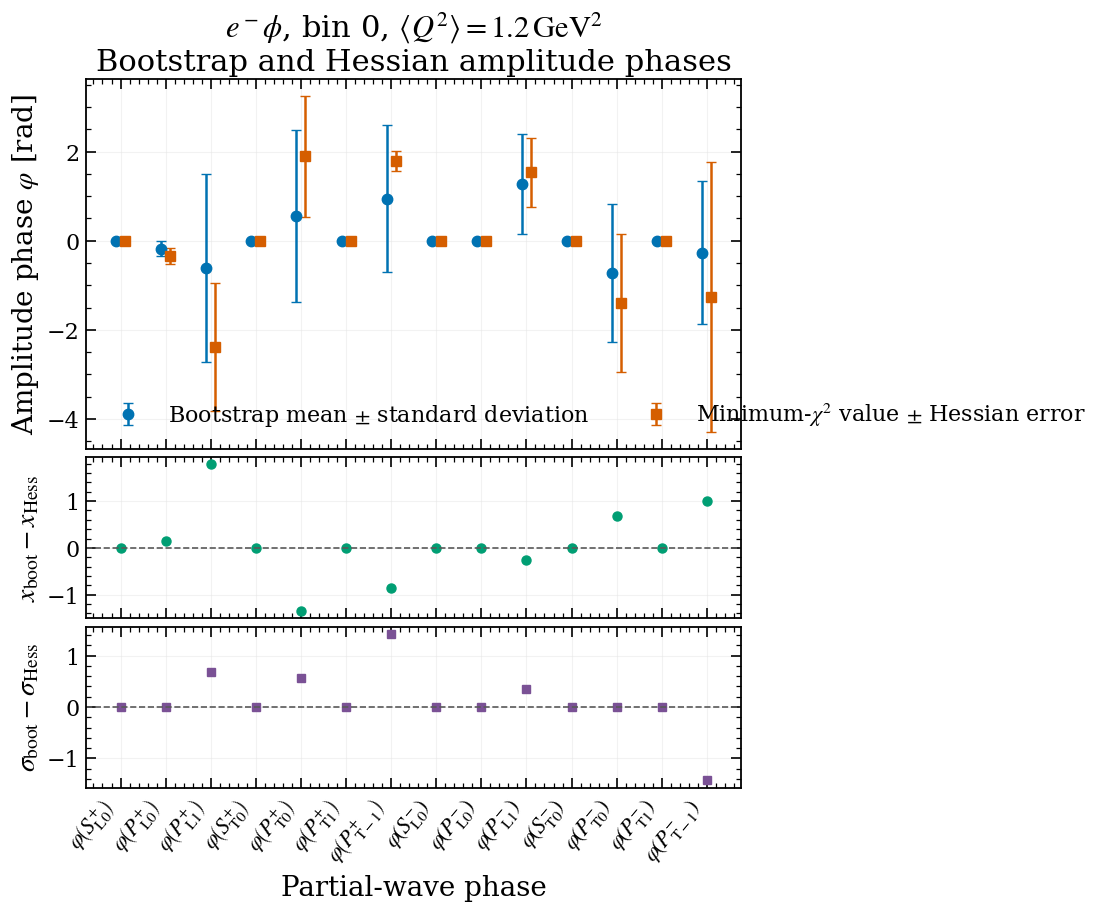

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElPhi_0/ElPhi_0_bootstrap_vs_hessian_phases.png


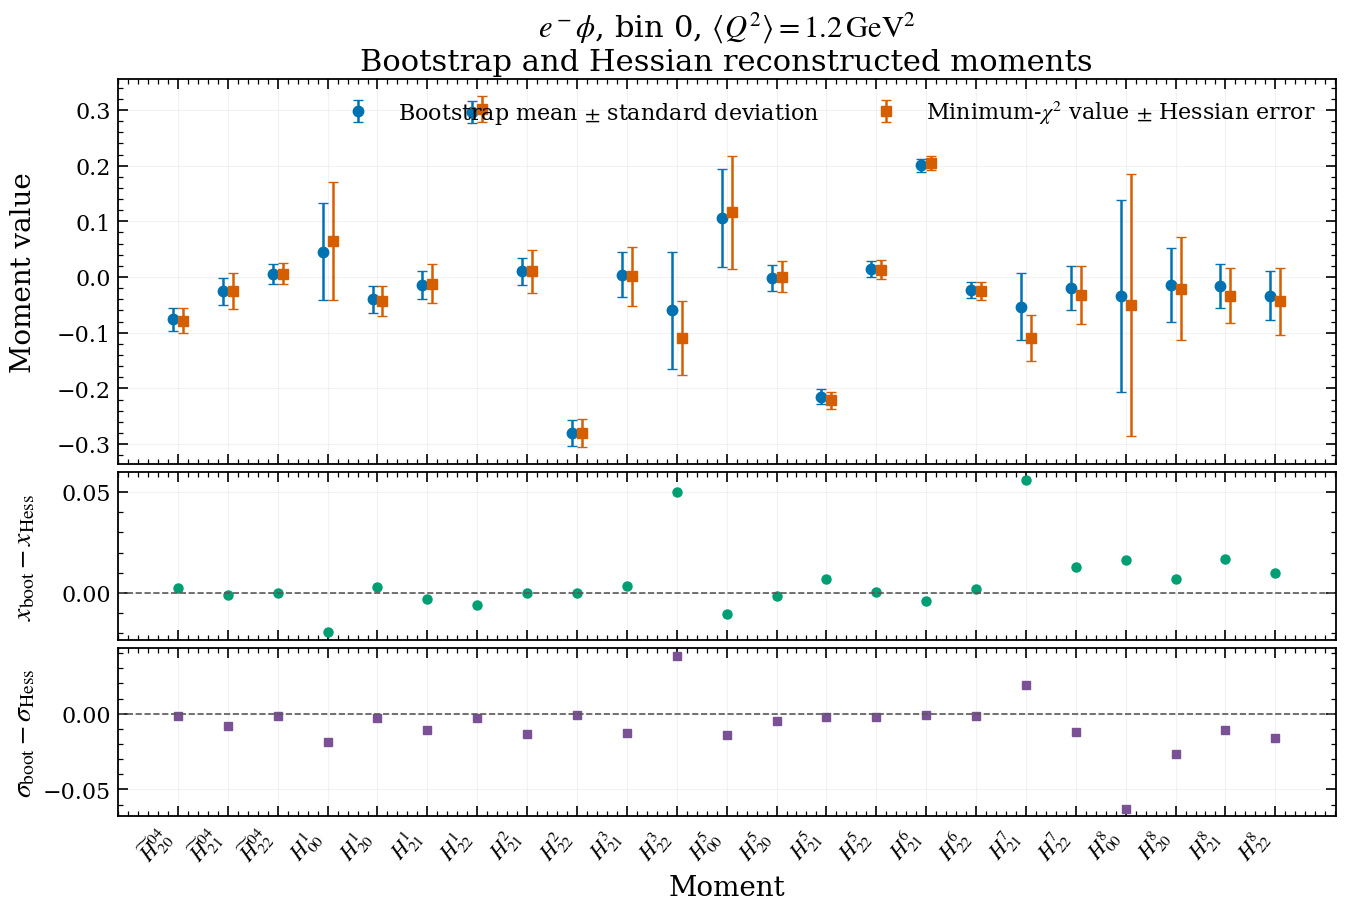

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElPhi_0/ElPhi_0_bootstrap_vs_hessian_moments.png
ElPhi_1: bootstrap 989/1000 replicas; Hessian entry 11284/100000, chi2=3.70936046804


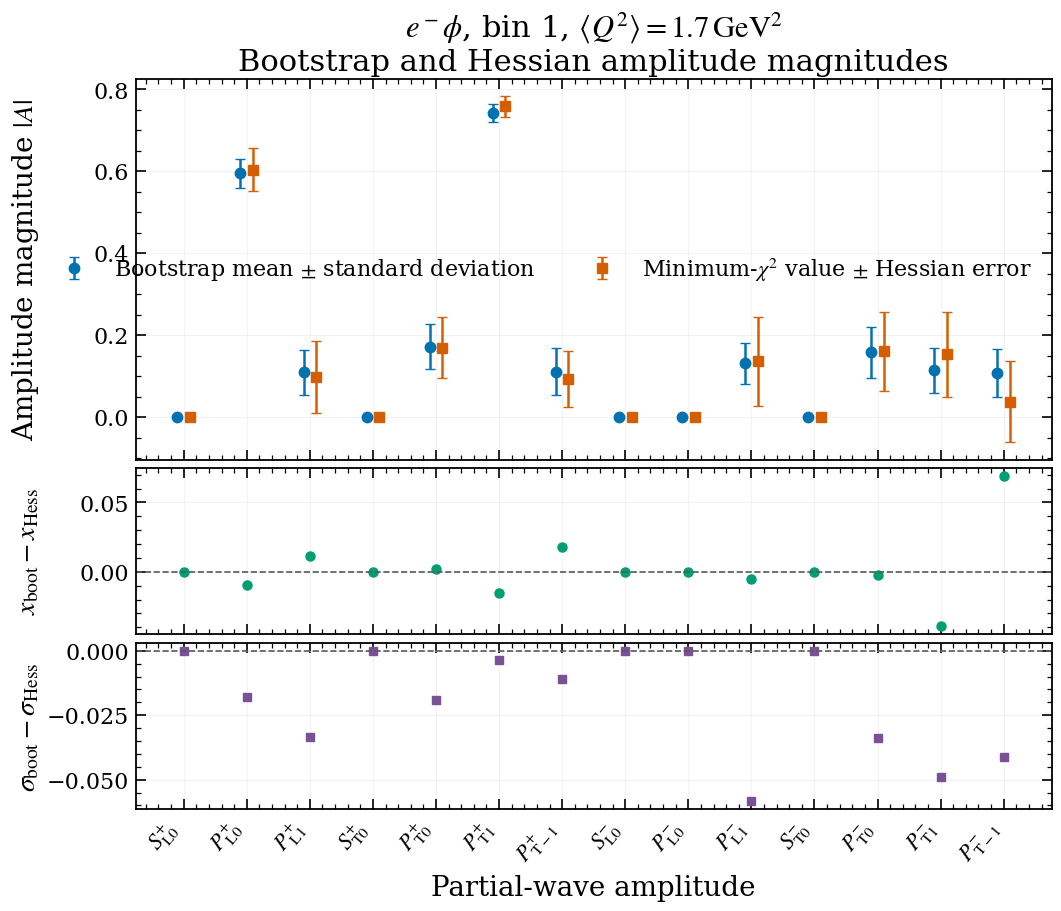

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElPhi_1/ElPhi_1_bootstrap_vs_hessian_amplitudes.png


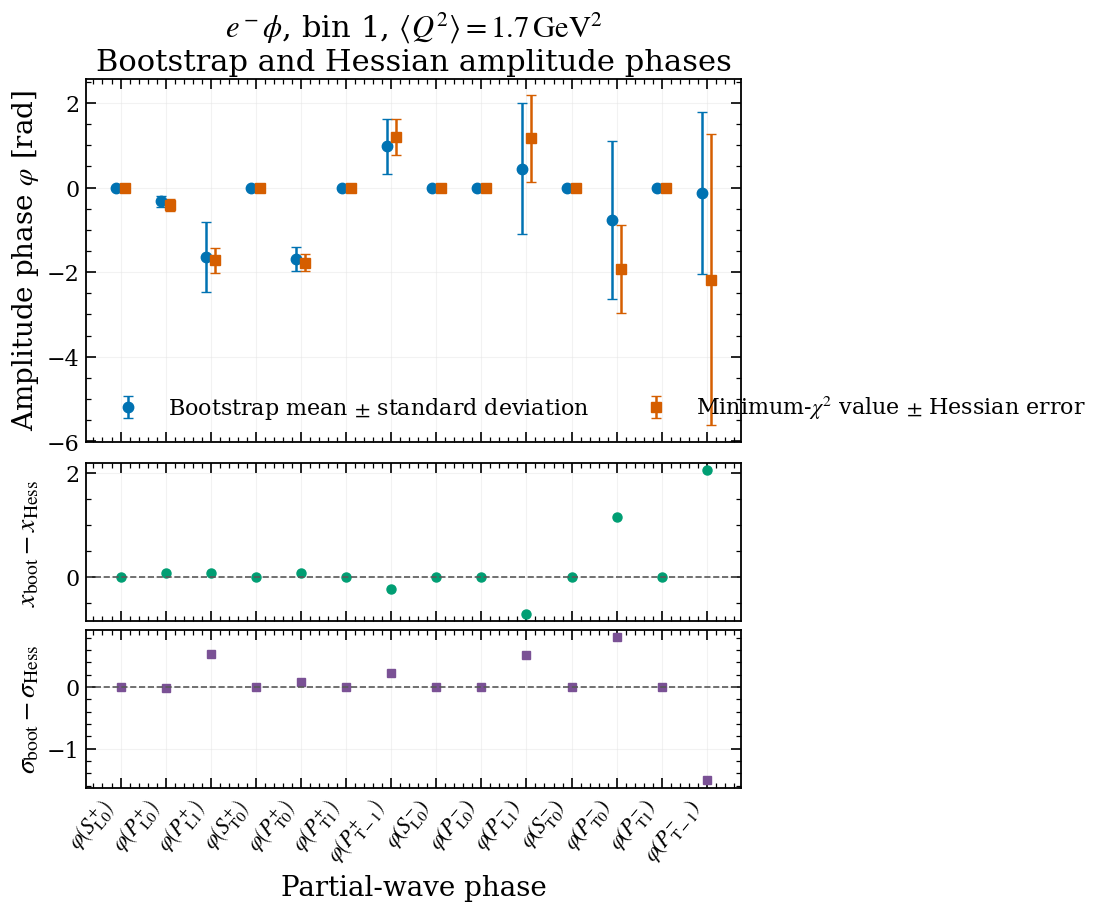

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElPhi_1/ElPhi_1_bootstrap_vs_hessian_phases.png


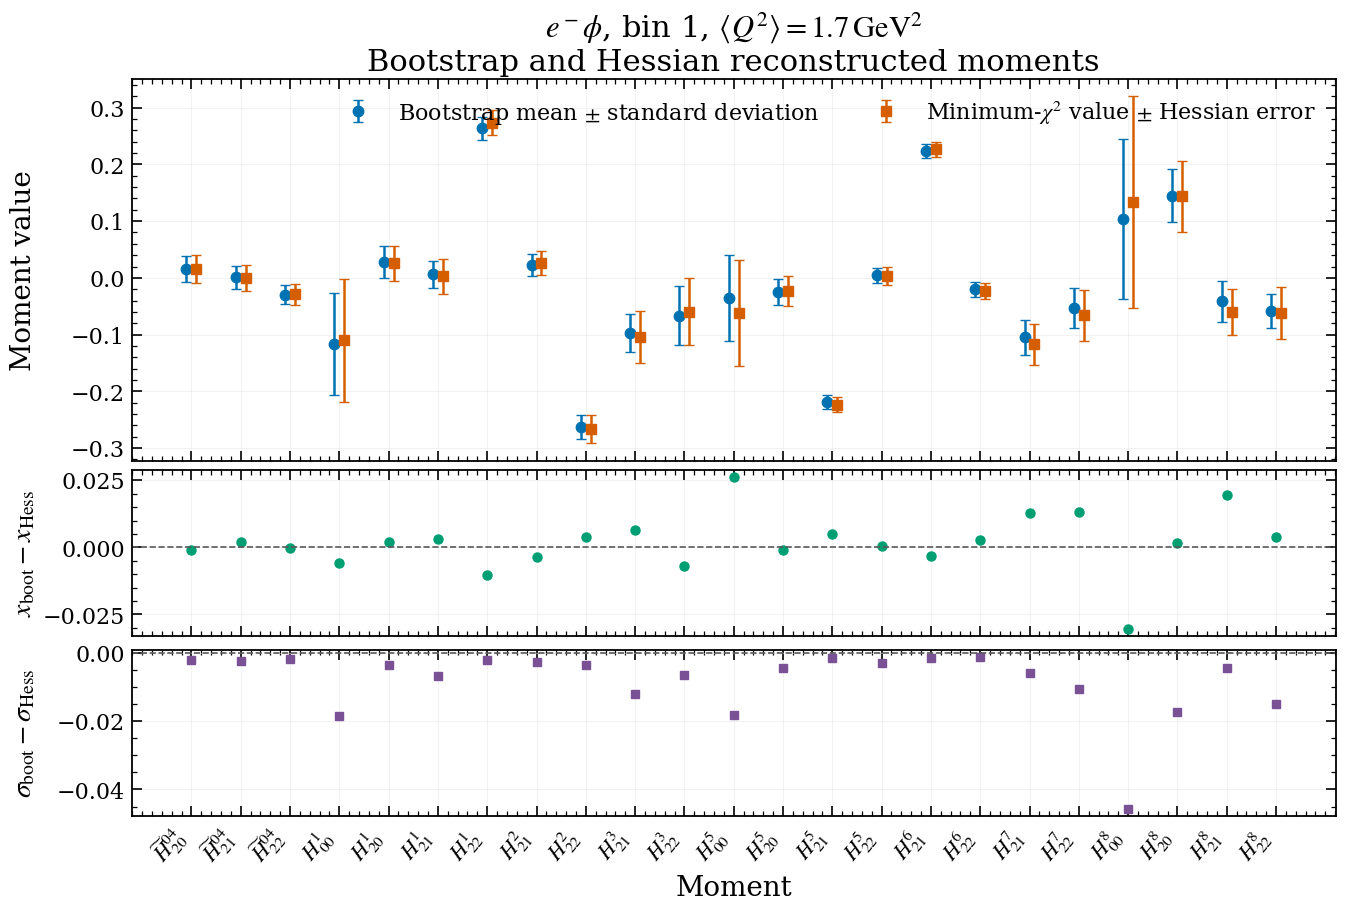

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElPhi_1/ElPhi_1_bootstrap_vs_hessian_moments.png
ElPhi_2: bootstrap 990/1000 replicas; Hessian entry 50138/100000, chi2=10.877954789


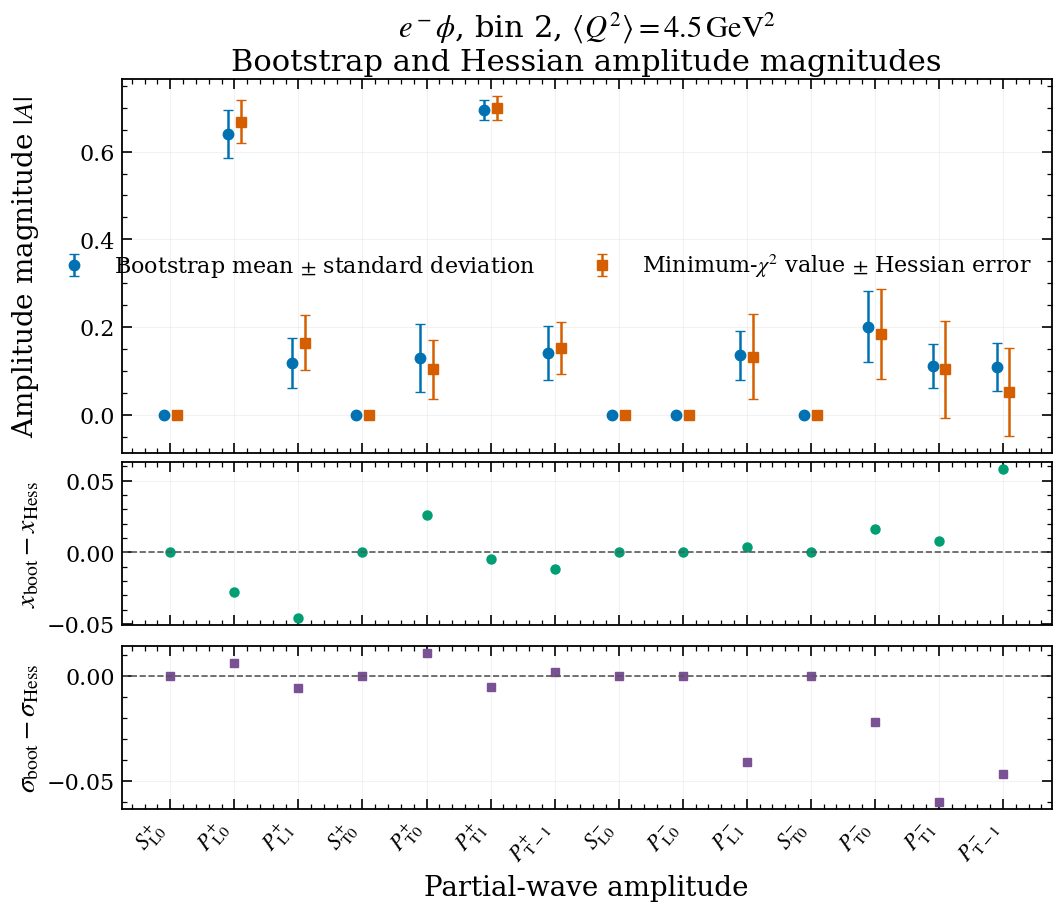

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElPhi_2/ElPhi_2_bootstrap_vs_hessian_amplitudes.png


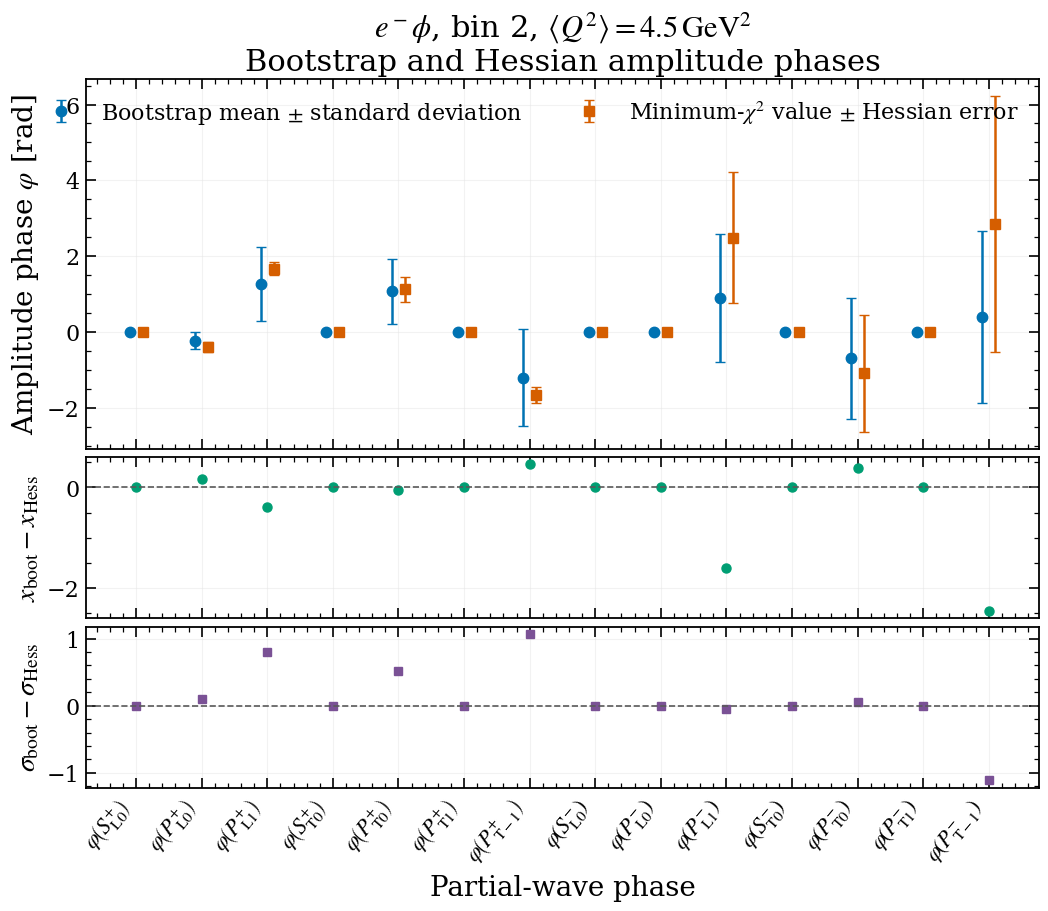

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElPhi_2/ElPhi_2_bootstrap_vs_hessian_phases.png


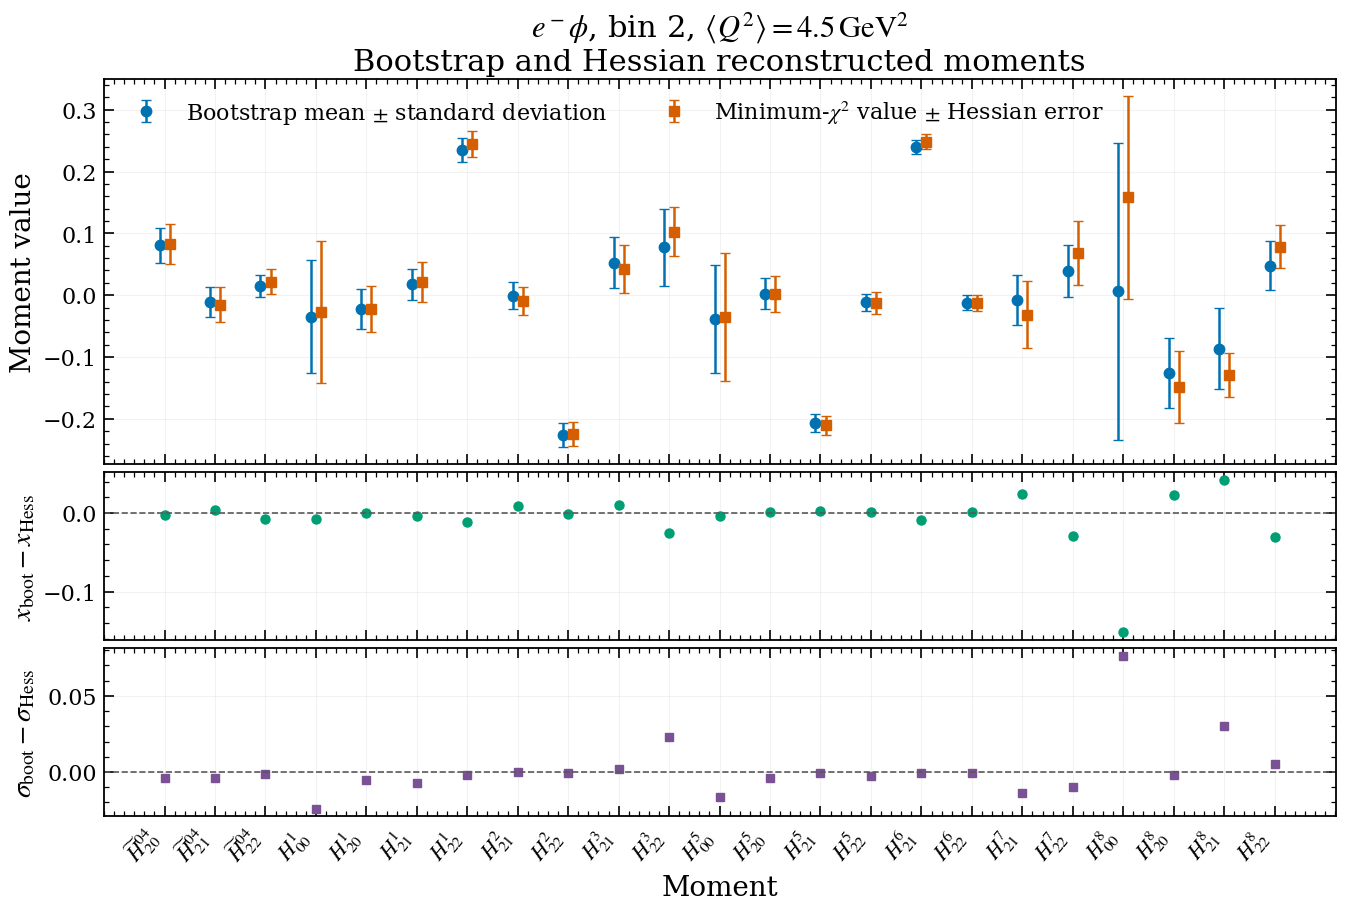

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElPhi_2/ElPhi_2_bootstrap_vs_hessian_moments.png
ElRho_0: bootstrap 959/1000 replicas; Hessian entry 11209/100000, chi2=2.56664622902


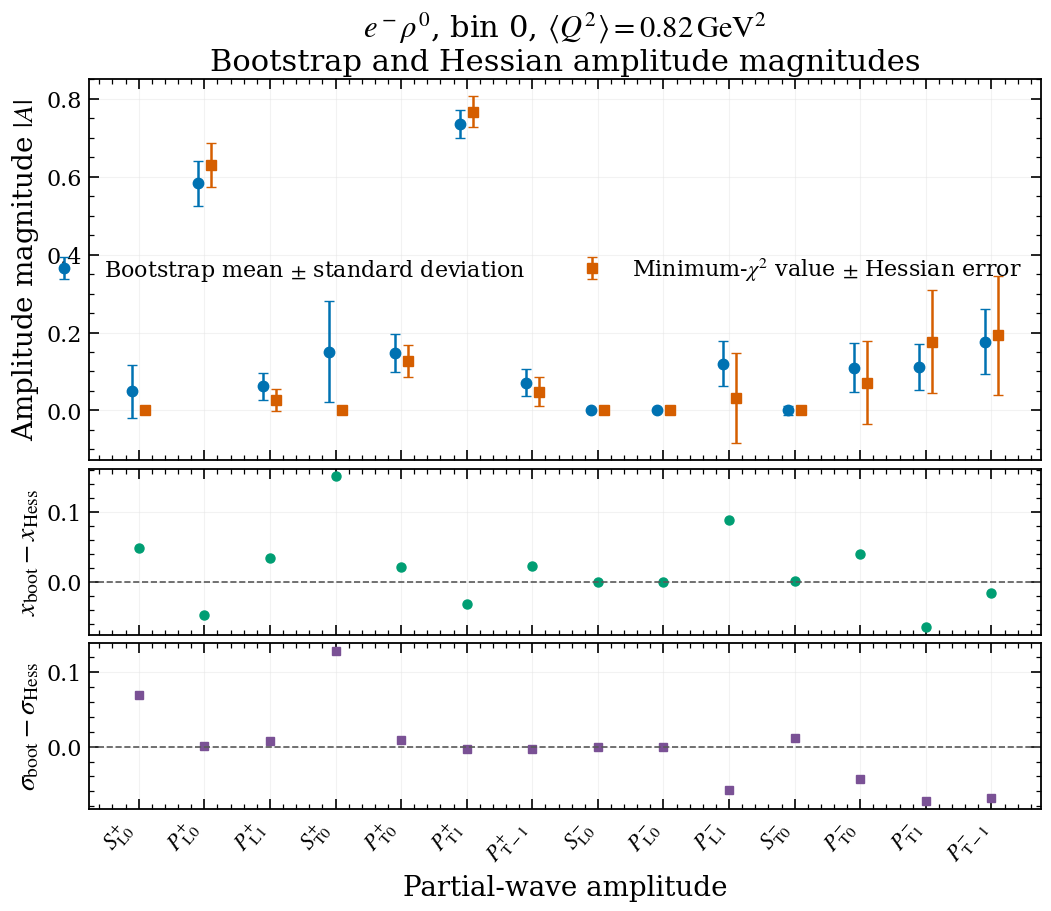

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_0/ElRho_0_bootstrap_vs_hessian_amplitudes.png


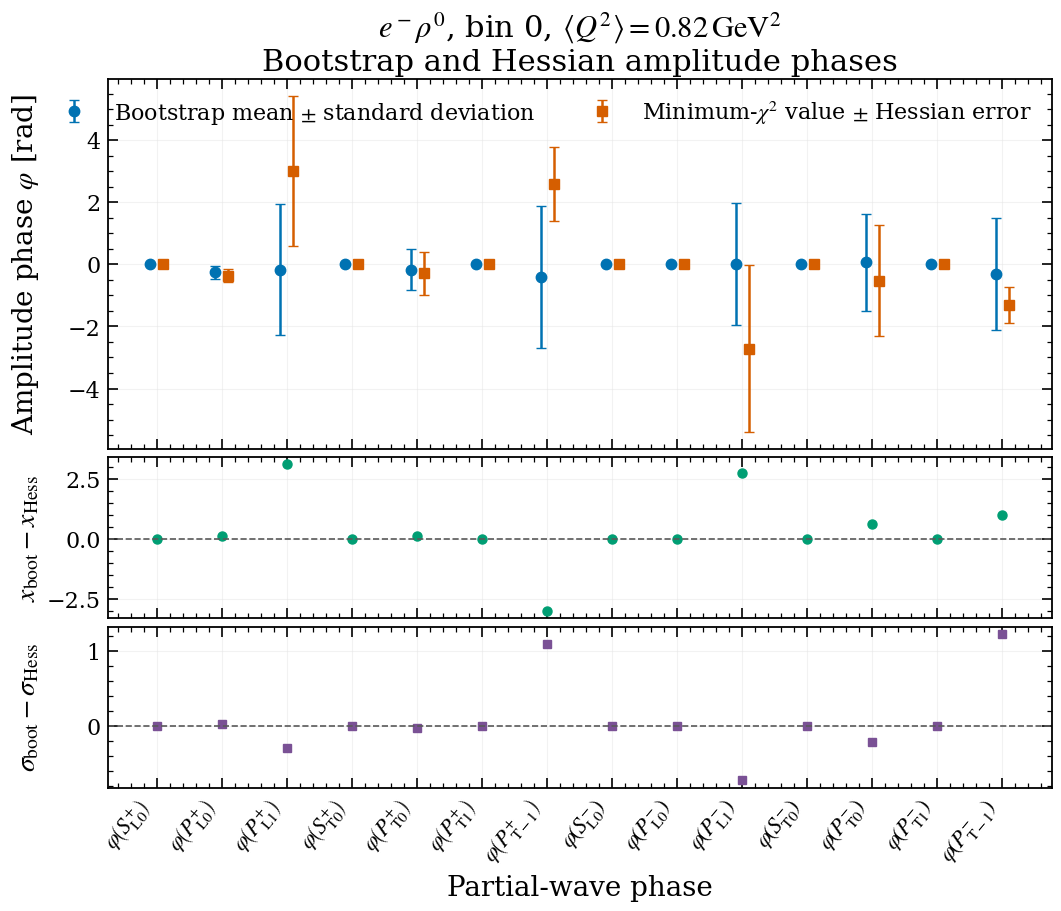

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_0/ElRho_0_bootstrap_vs_hessian_phases.png


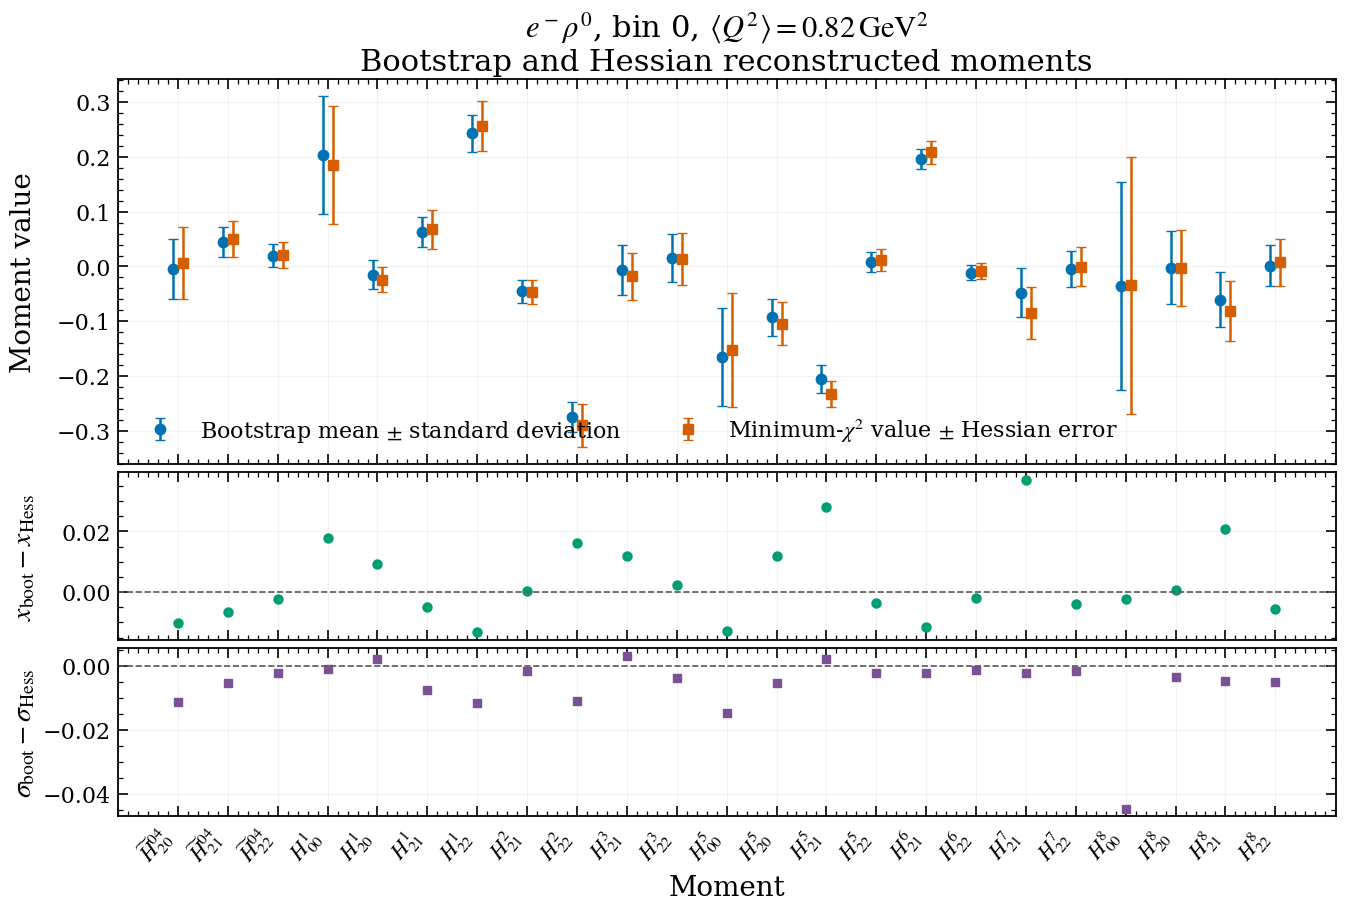

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_0/ElRho_0_bootstrap_vs_hessian_moments.png
ElRho_1: bootstrap 951/1000 replicas; Hessian entry 16657/100000, chi2=4.2057122062


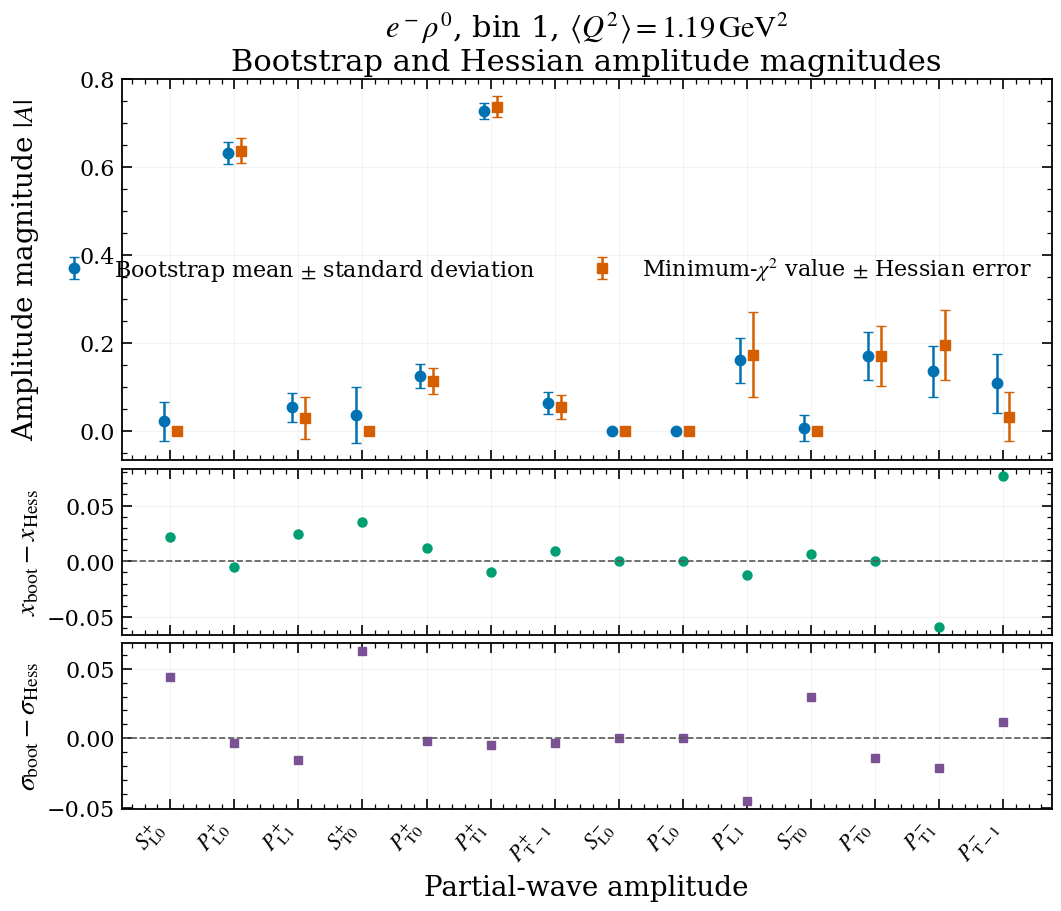

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_1/ElRho_1_bootstrap_vs_hessian_amplitudes.png


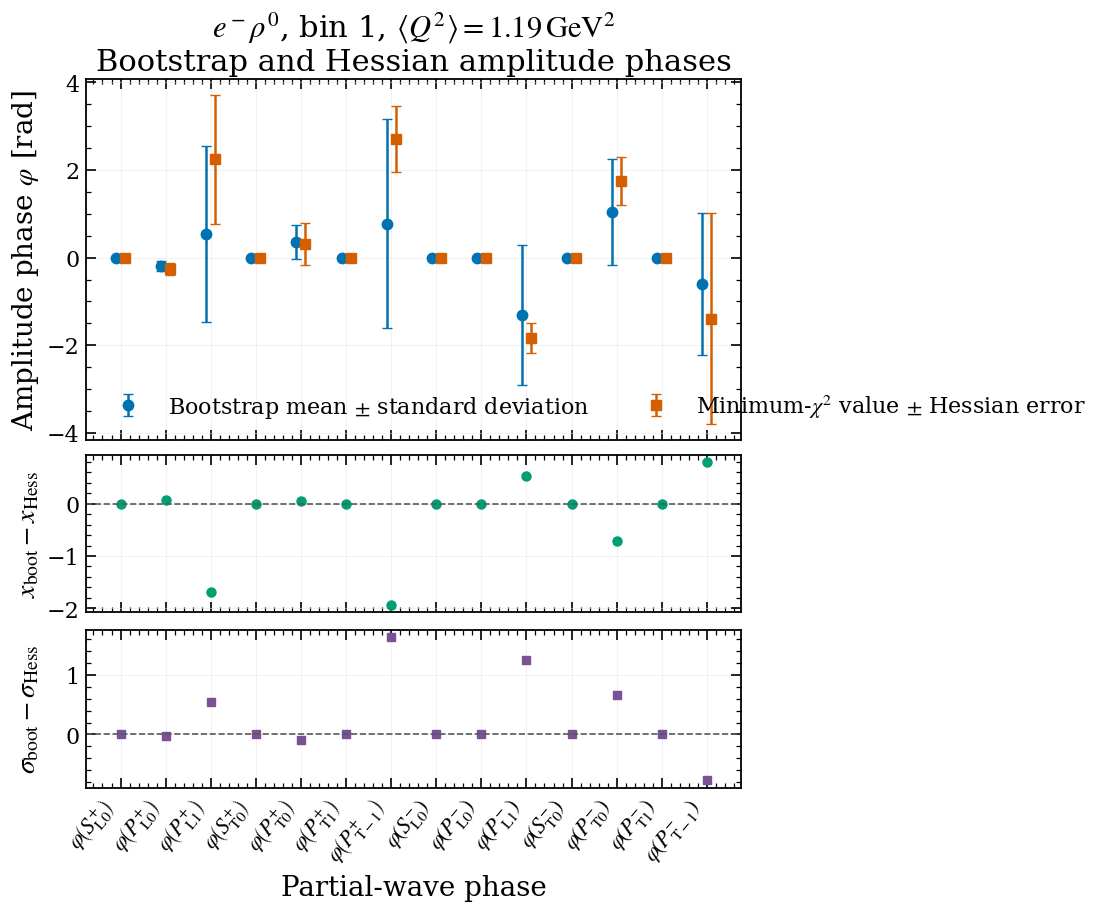

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_1/ElRho_1_bootstrap_vs_hessian_phases.png


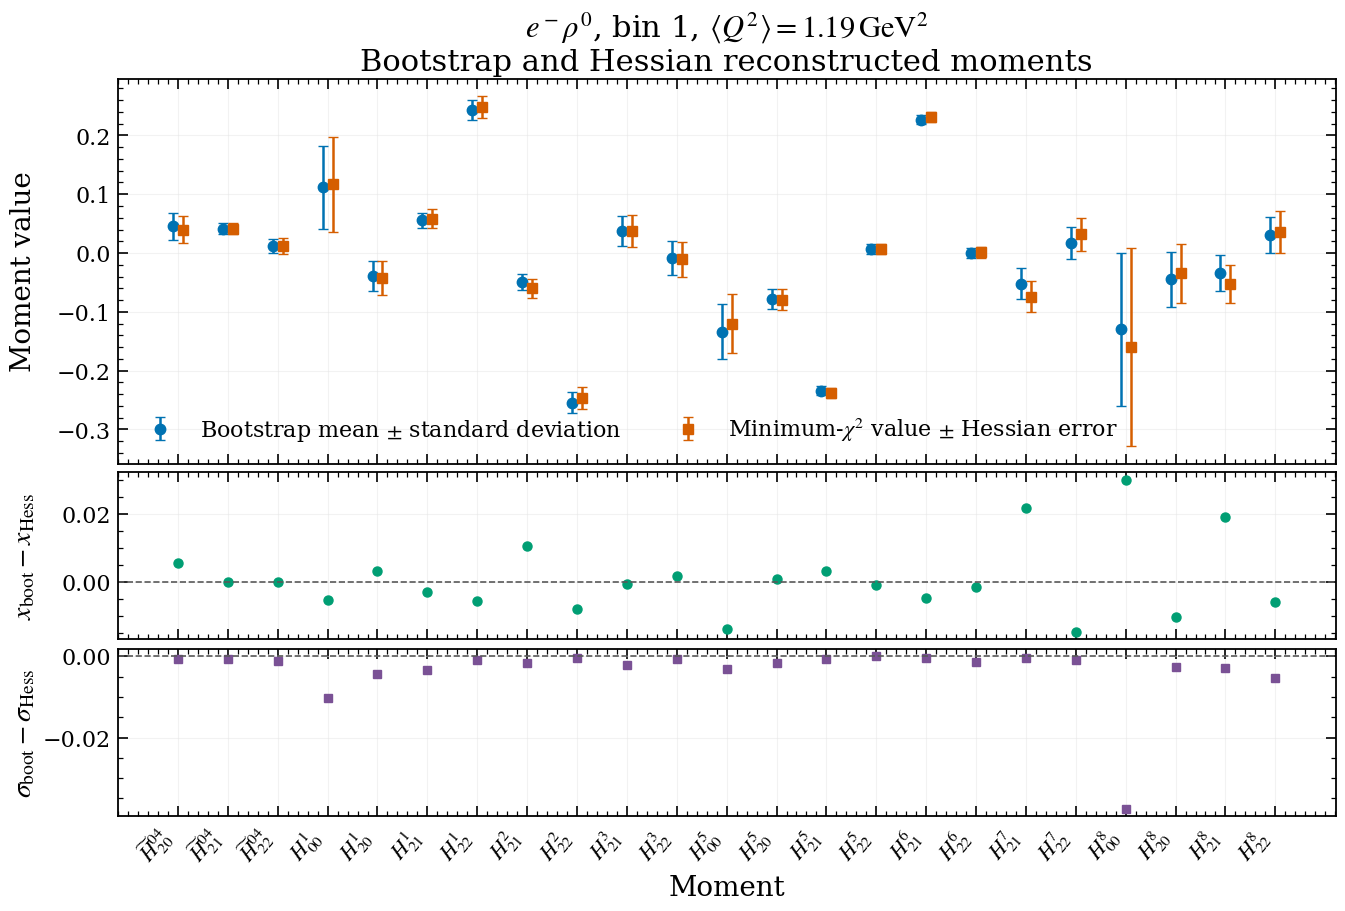

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_1/ElRho_1_bootstrap_vs_hessian_moments.png
ElRho_2: bootstrap 919/1000 replicas; Hessian entry 6218/100000, chi2=3.87687916064


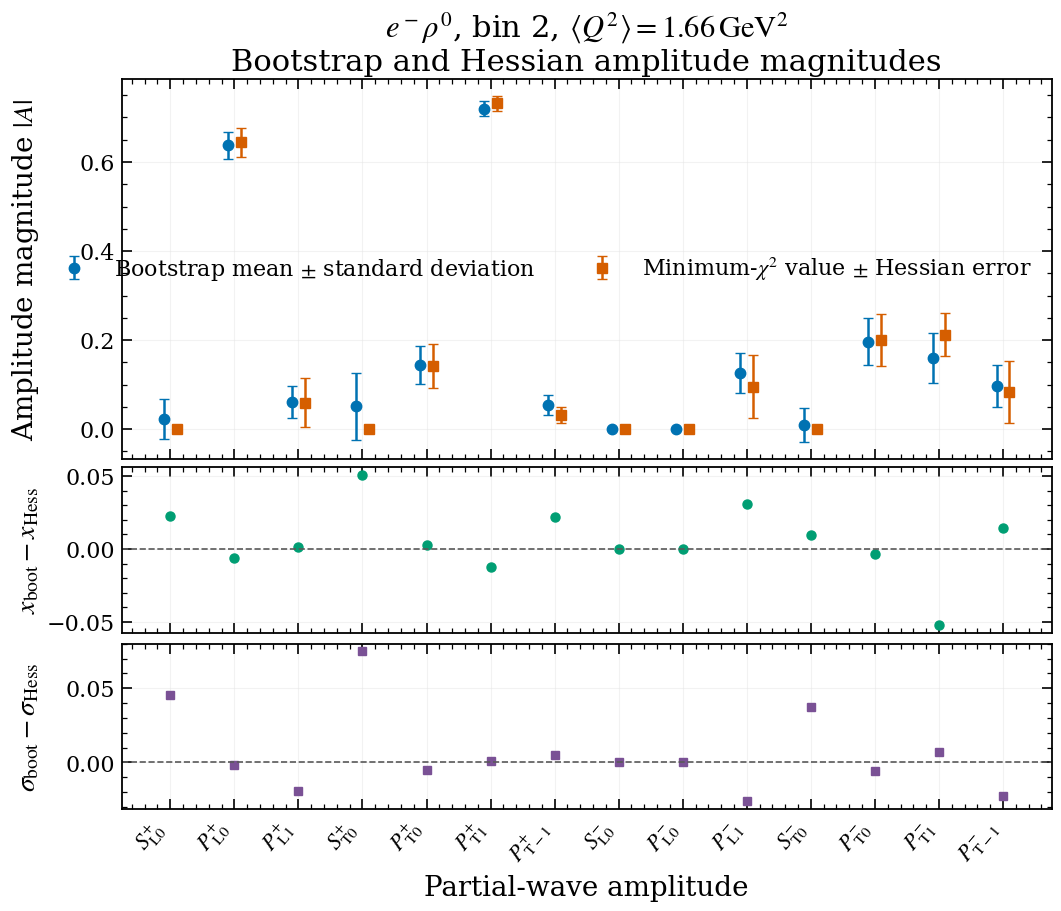

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_2/ElRho_2_bootstrap_vs_hessian_amplitudes.png


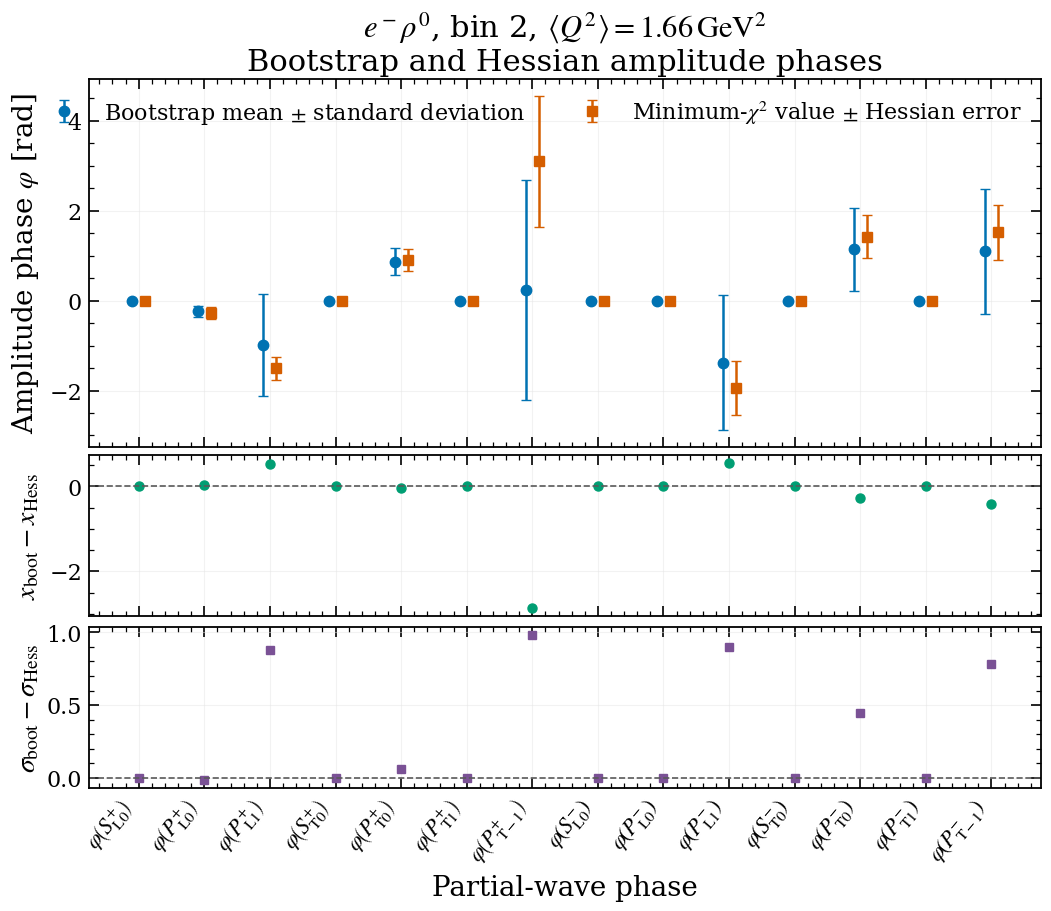

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_2/ElRho_2_bootstrap_vs_hessian_phases.png


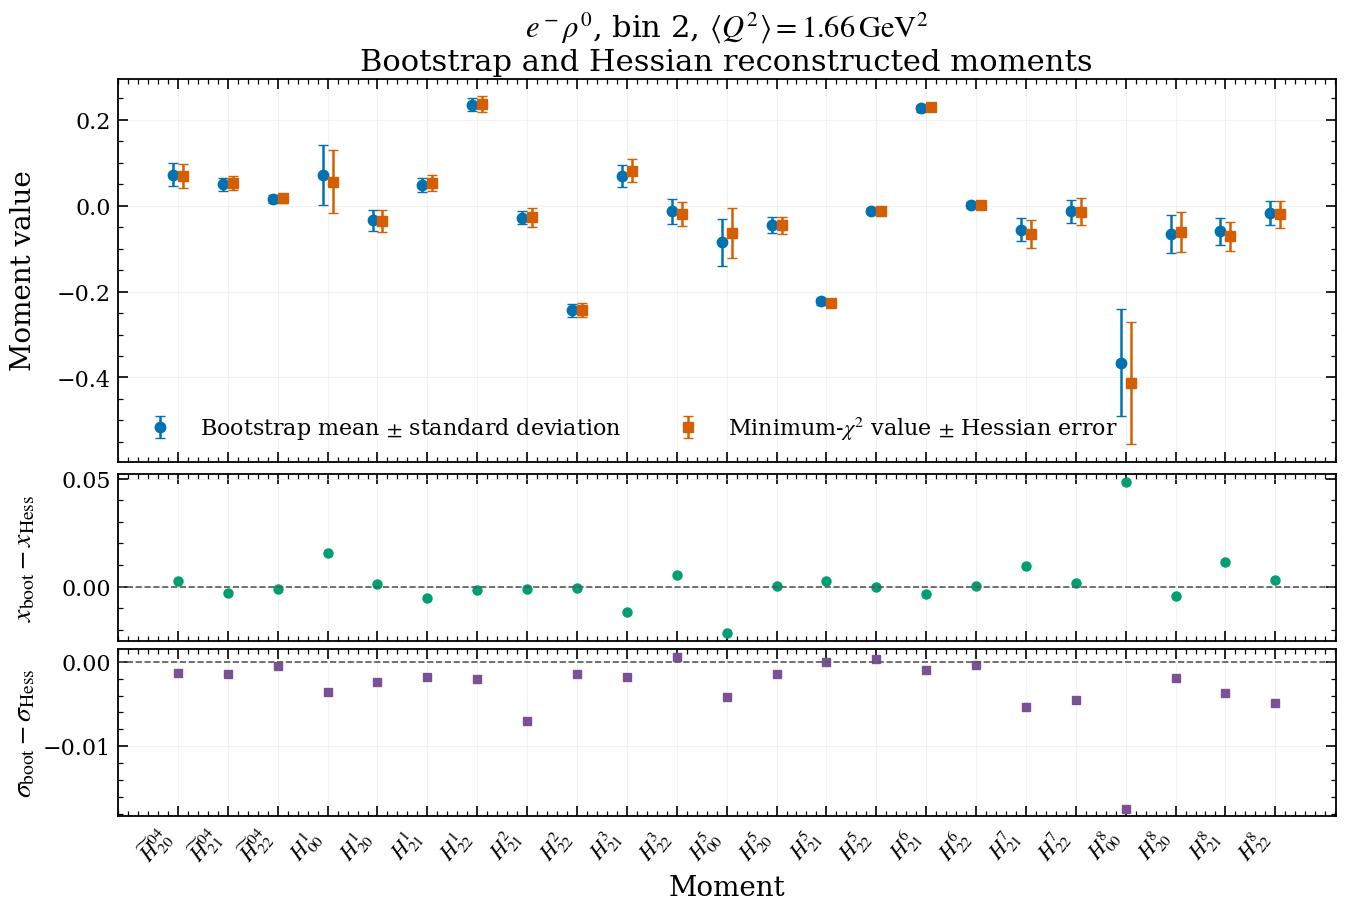

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_2/ElRho_2_bootstrap_vs_hessian_moments.png
ElRho_3: bootstrap 973/1000 replicas; Hessian entry 82542/100000, chi2=8.37153882778


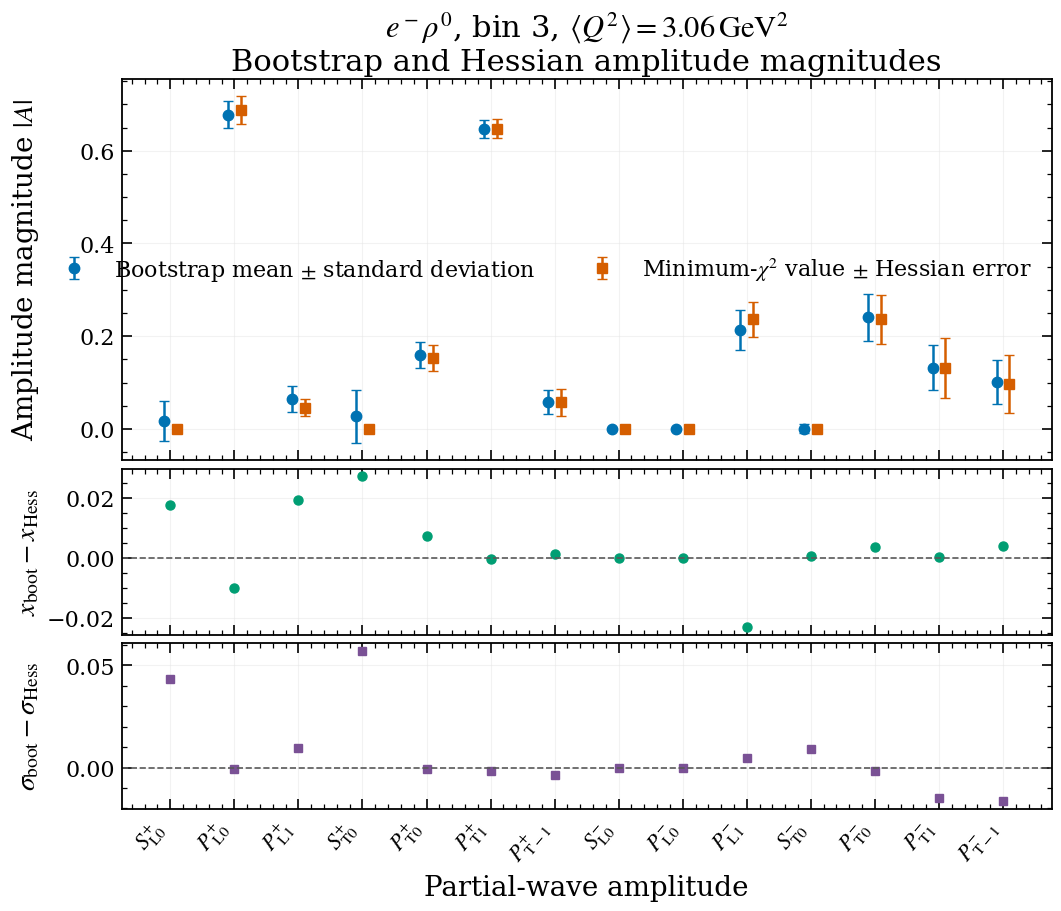

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_3/ElRho_3_bootstrap_vs_hessian_amplitudes.png


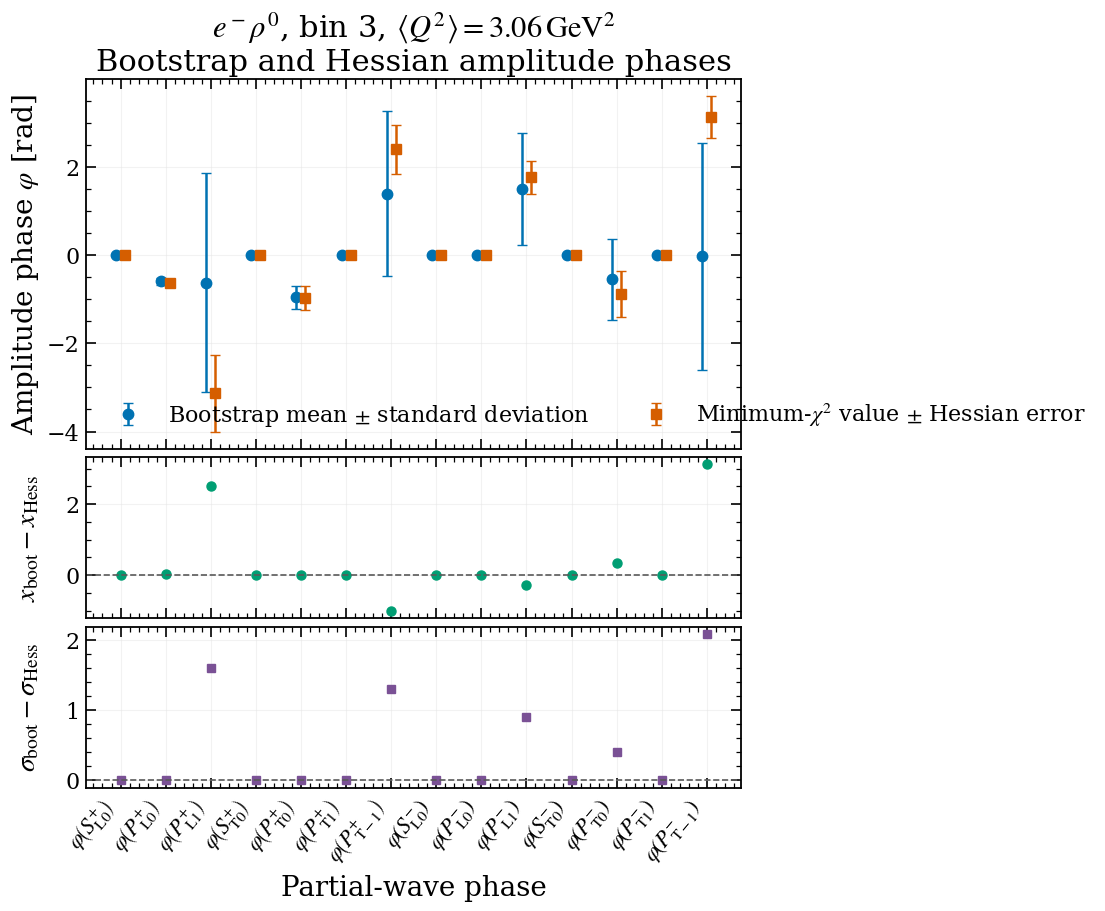

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_3/ElRho_3_bootstrap_vs_hessian_phases.png


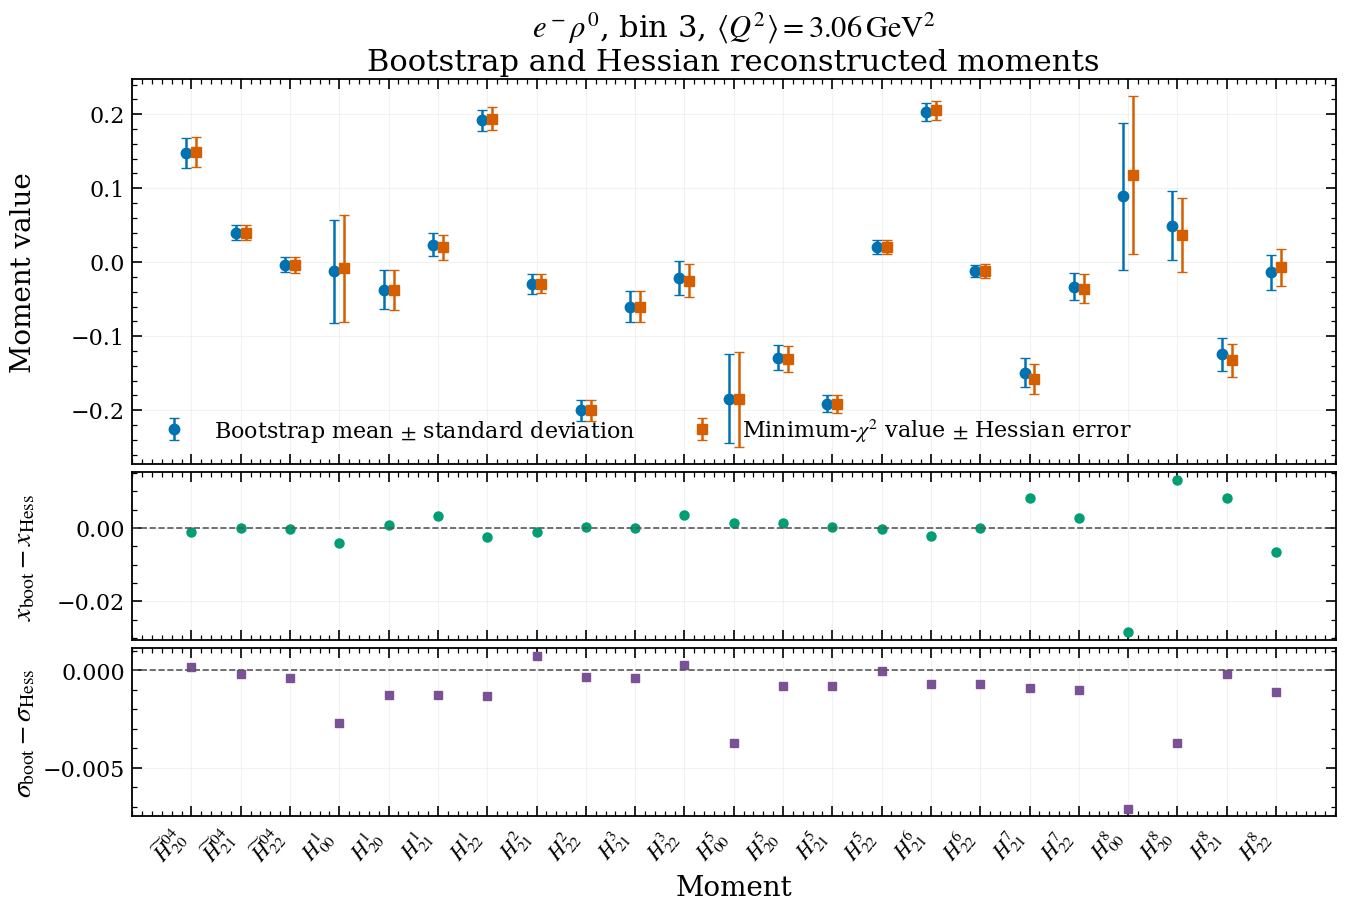

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_3/ElRho_3_bootstrap_vs_hessian_moments.png
MuOmega_0: bootstrap 957/1000 replicas; Hessian entry 92998/100000, chi2=1.92212519638


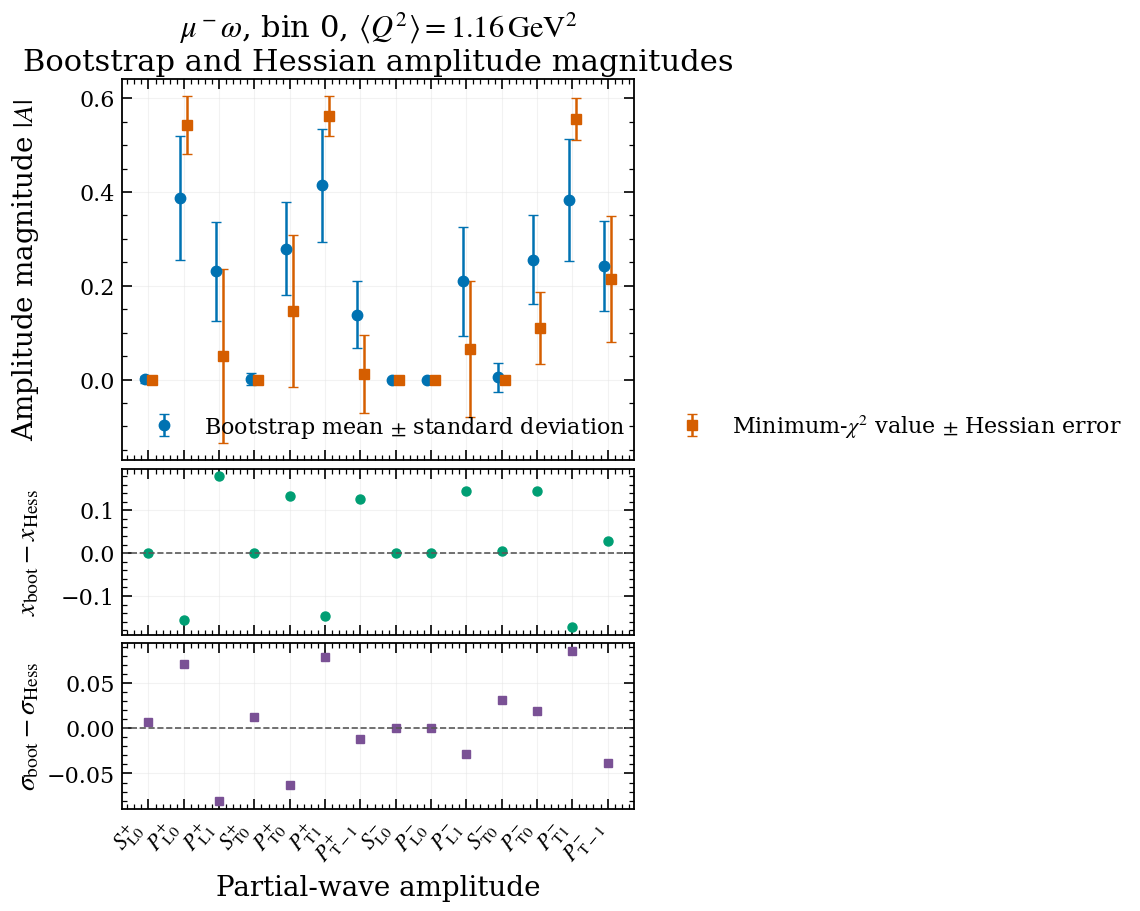

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuOmega_0/MuOmega_0_bootstrap_vs_hessian_amplitudes.png


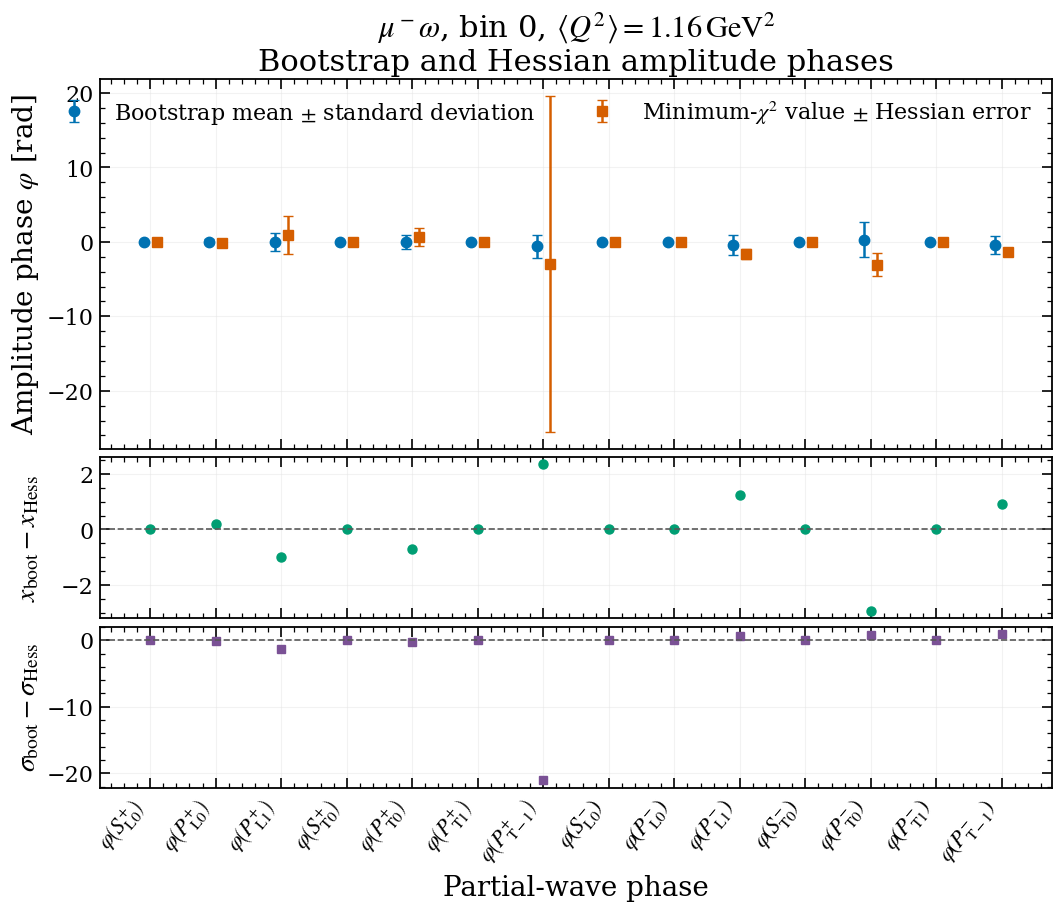

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuOmega_0/MuOmega_0_bootstrap_vs_hessian_phases.png


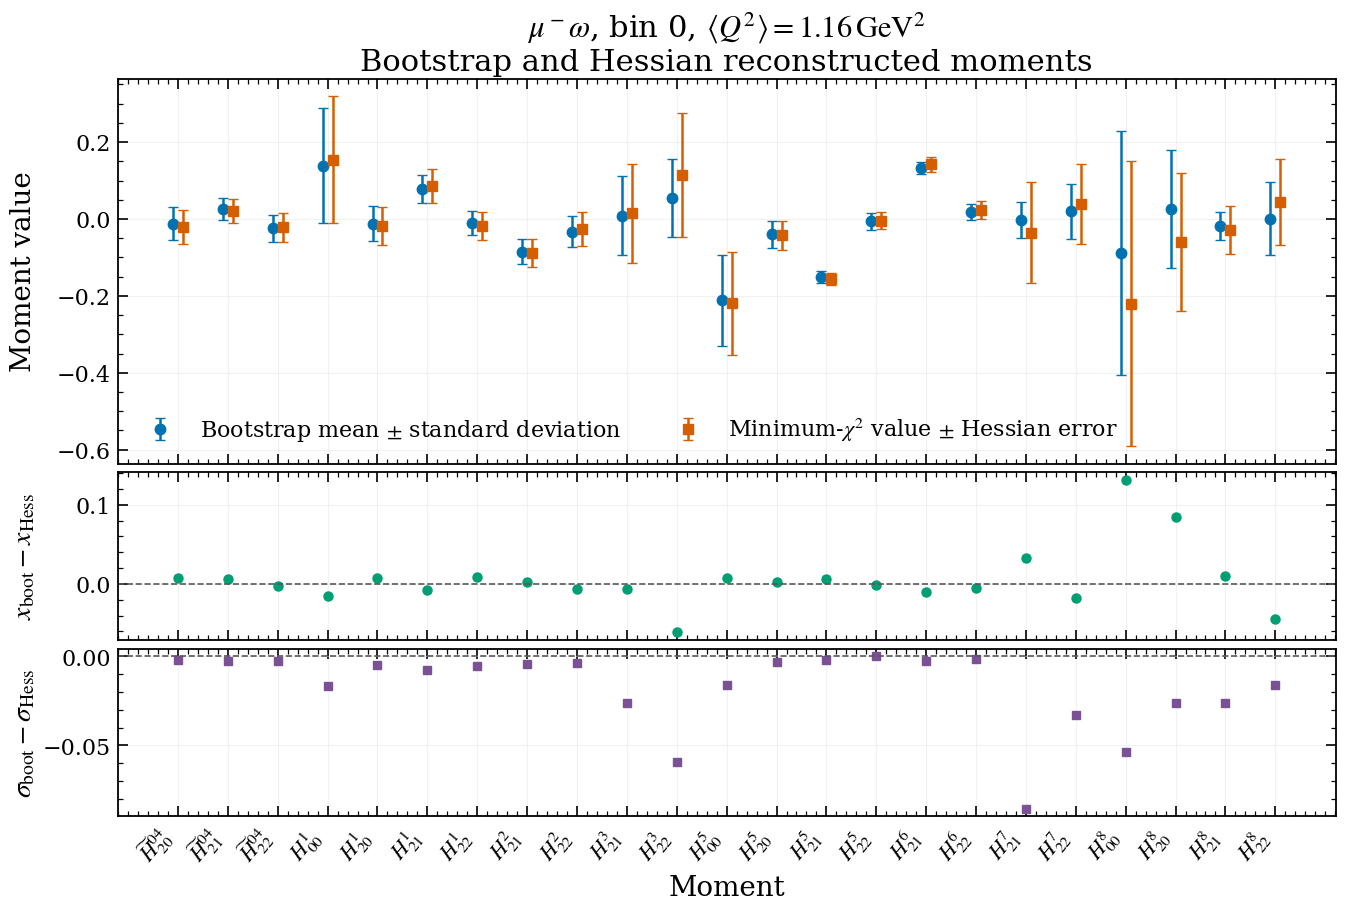

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuOmega_0/MuOmega_0_bootstrap_vs_hessian_moments.png
MuOmega_1: bootstrap 959/1000 replicas; Hessian entry 87453/100000, chi2=1.43796490804


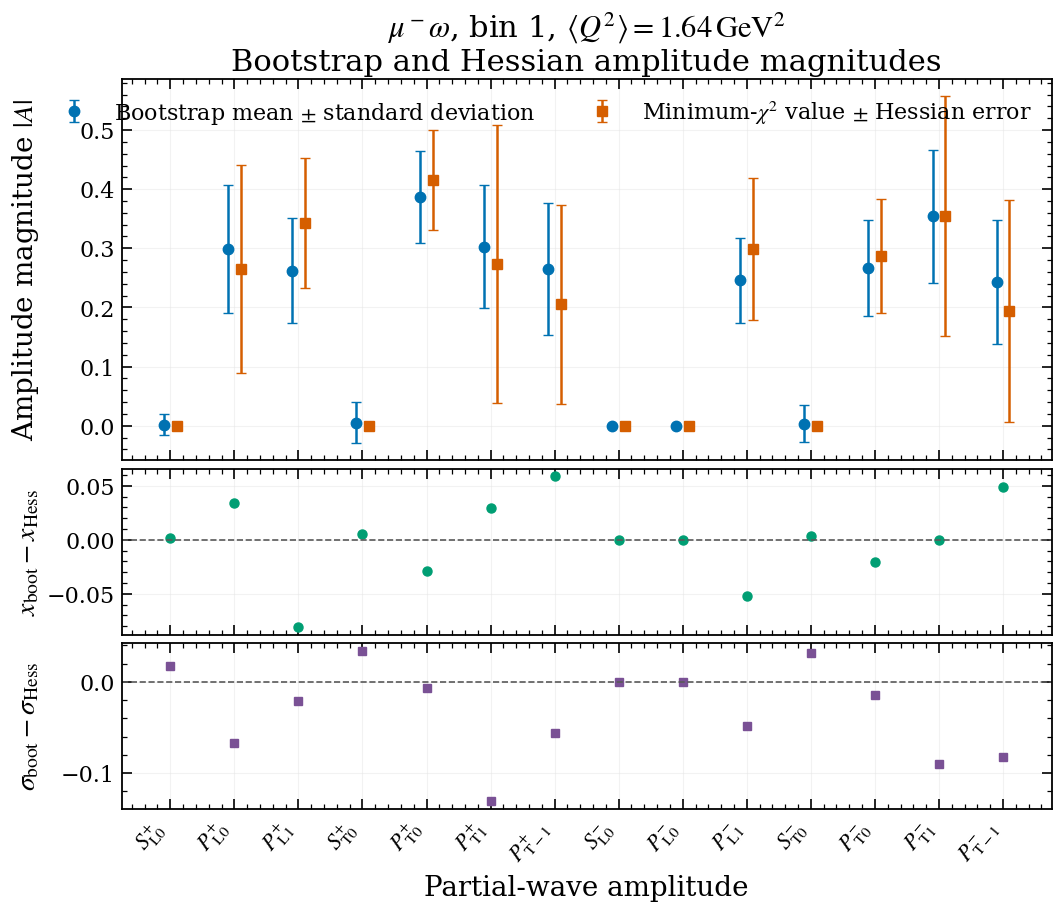

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuOmega_1/MuOmega_1_bootstrap_vs_hessian_amplitudes.png


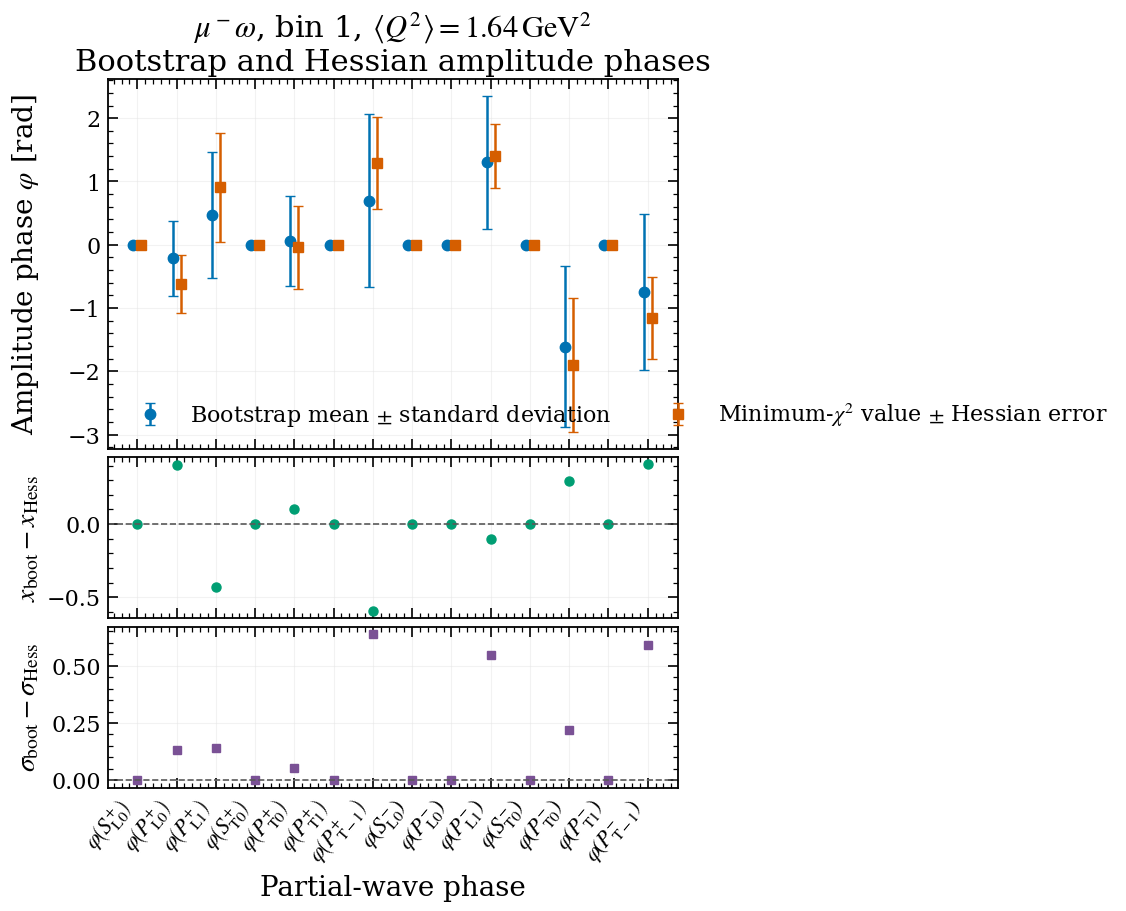

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuOmega_1/MuOmega_1_bootstrap_vs_hessian_phases.png


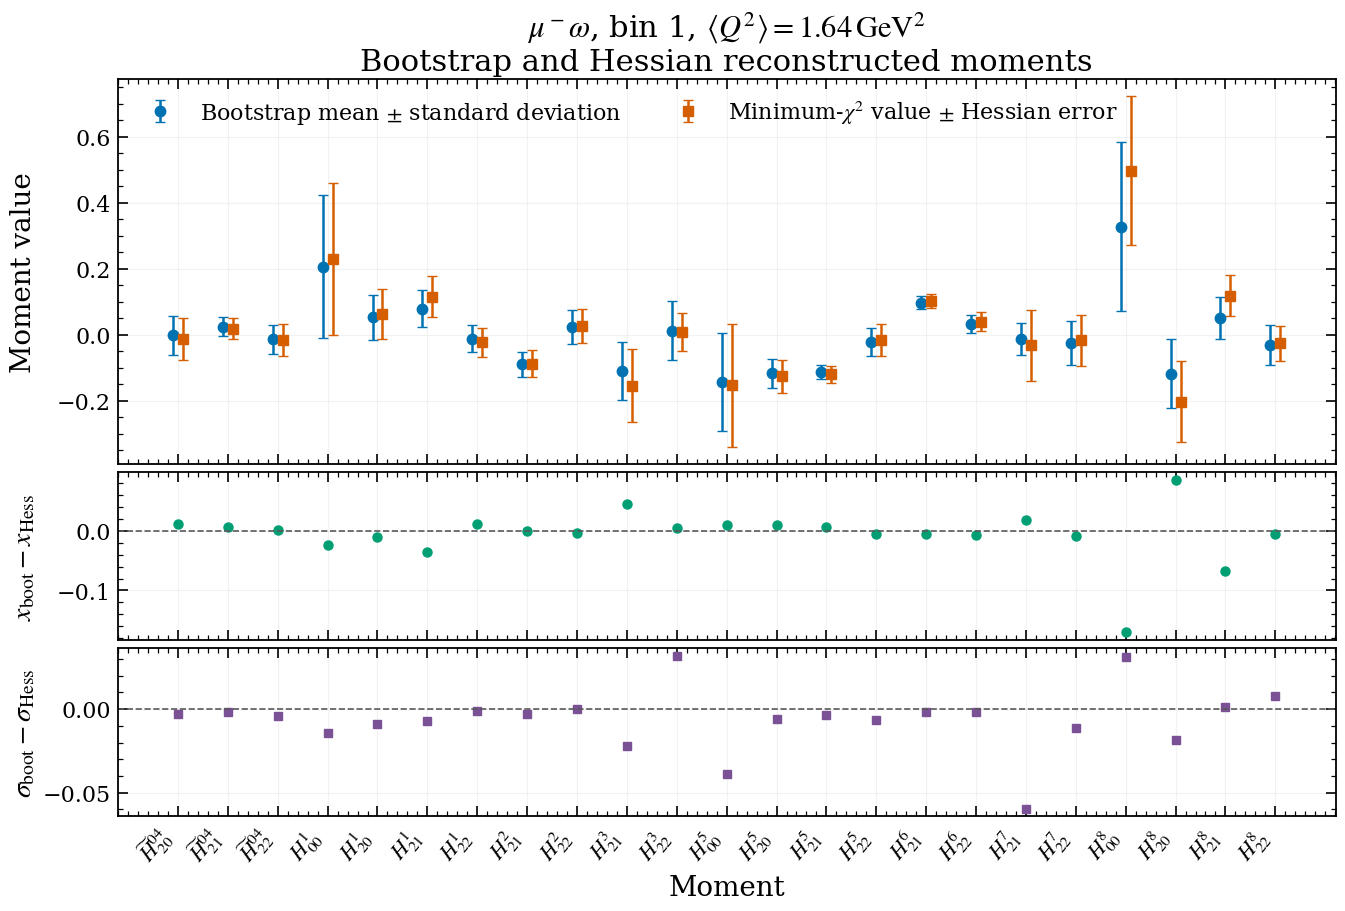

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuOmega_1/MuOmega_1_bootstrap_vs_hessian_moments.png
MuOmega_2: bootstrap 940/1000 replicas; Hessian entry 9817/100000, chi2=5.14309761731


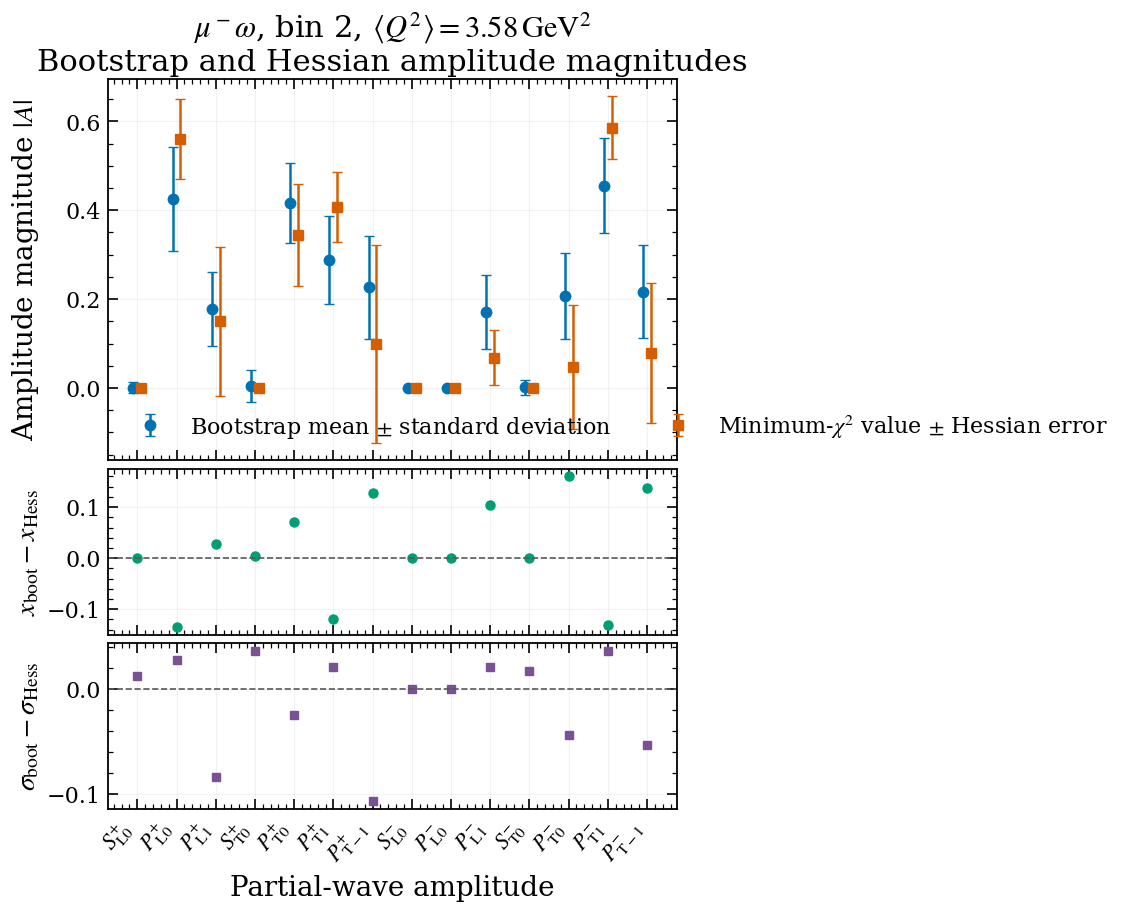

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuOmega_2/MuOmega_2_bootstrap_vs_hessian_amplitudes.png


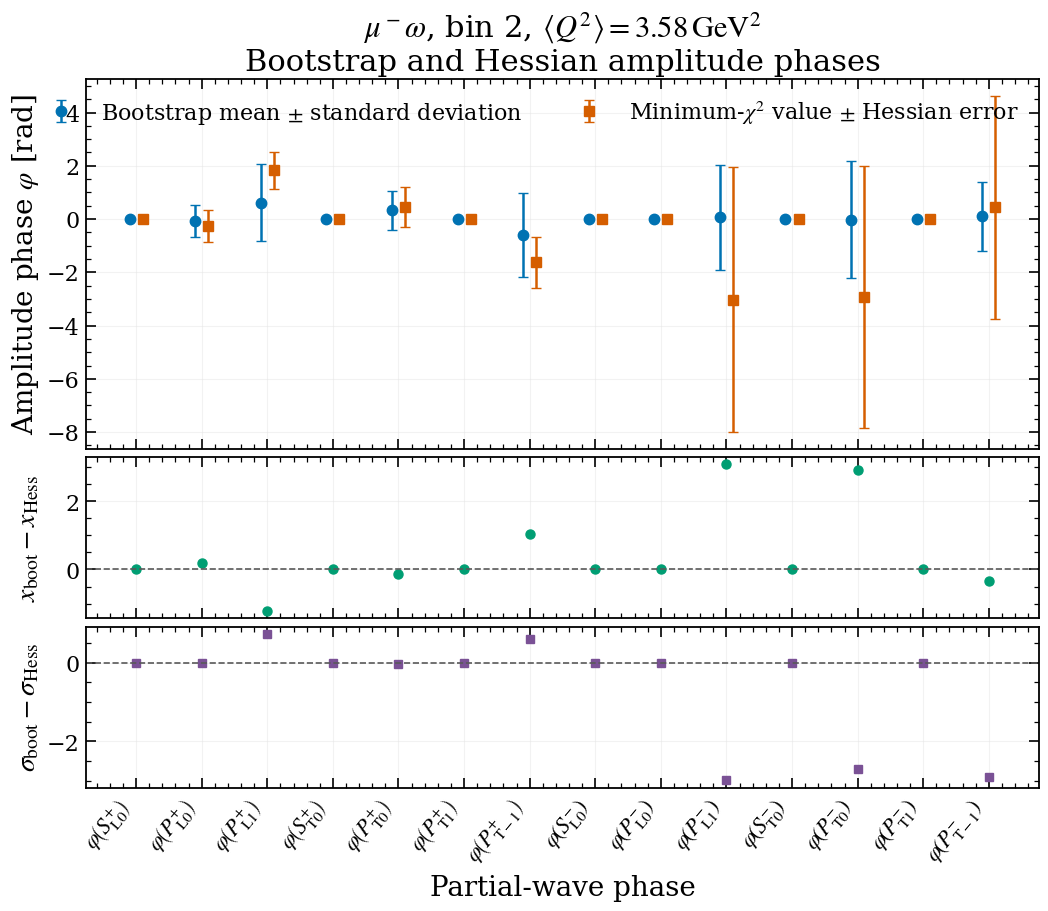

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuOmega_2/MuOmega_2_bootstrap_vs_hessian_phases.png


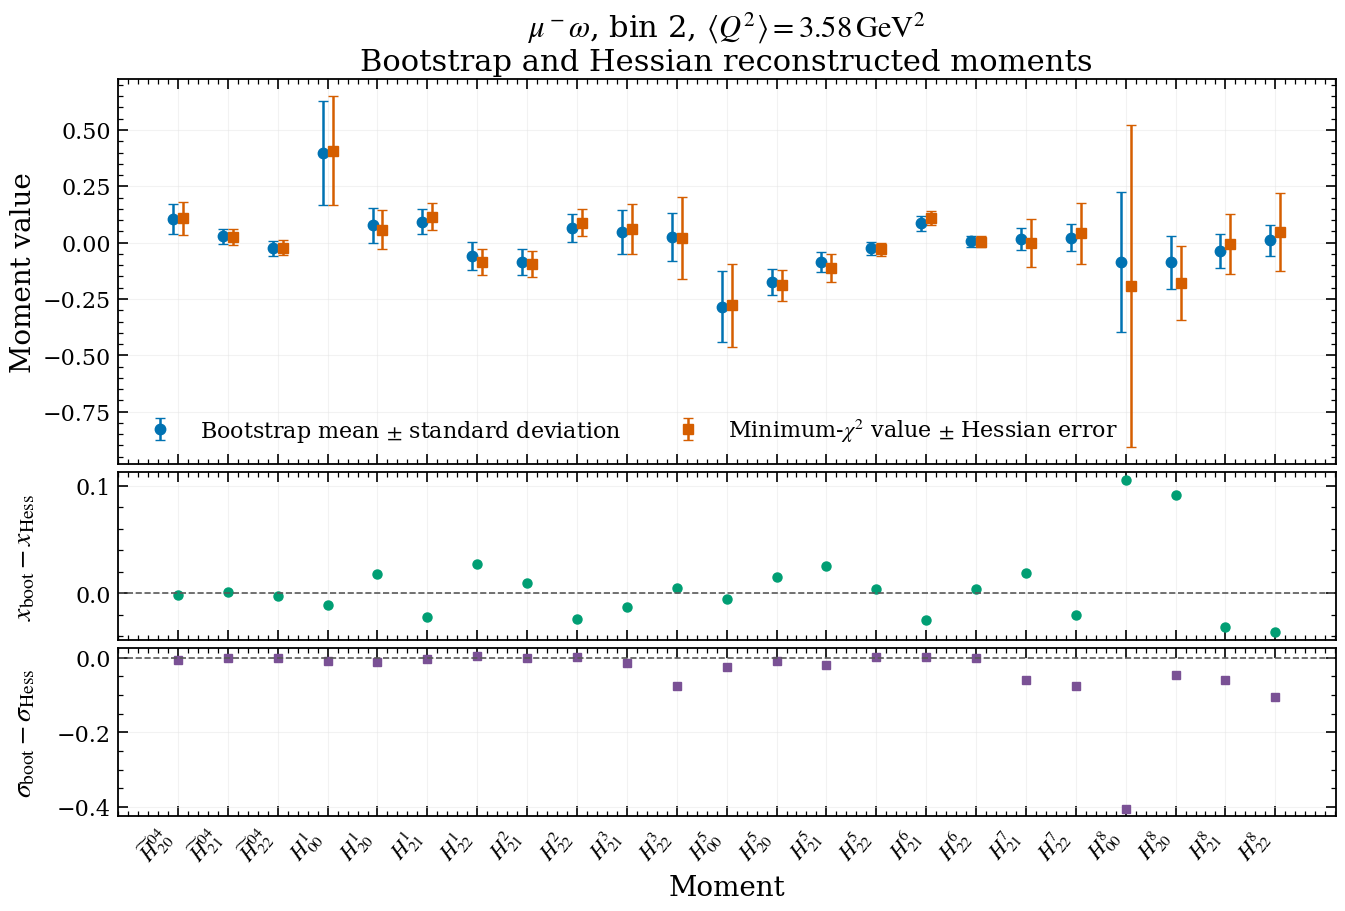

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuOmega_2/MuOmega_2_bootstrap_vs_hessian_moments.png
MuRho_0: bootstrap 876/1000 replicas; Hessian entry 82110/100000, chi2=1.68514714596


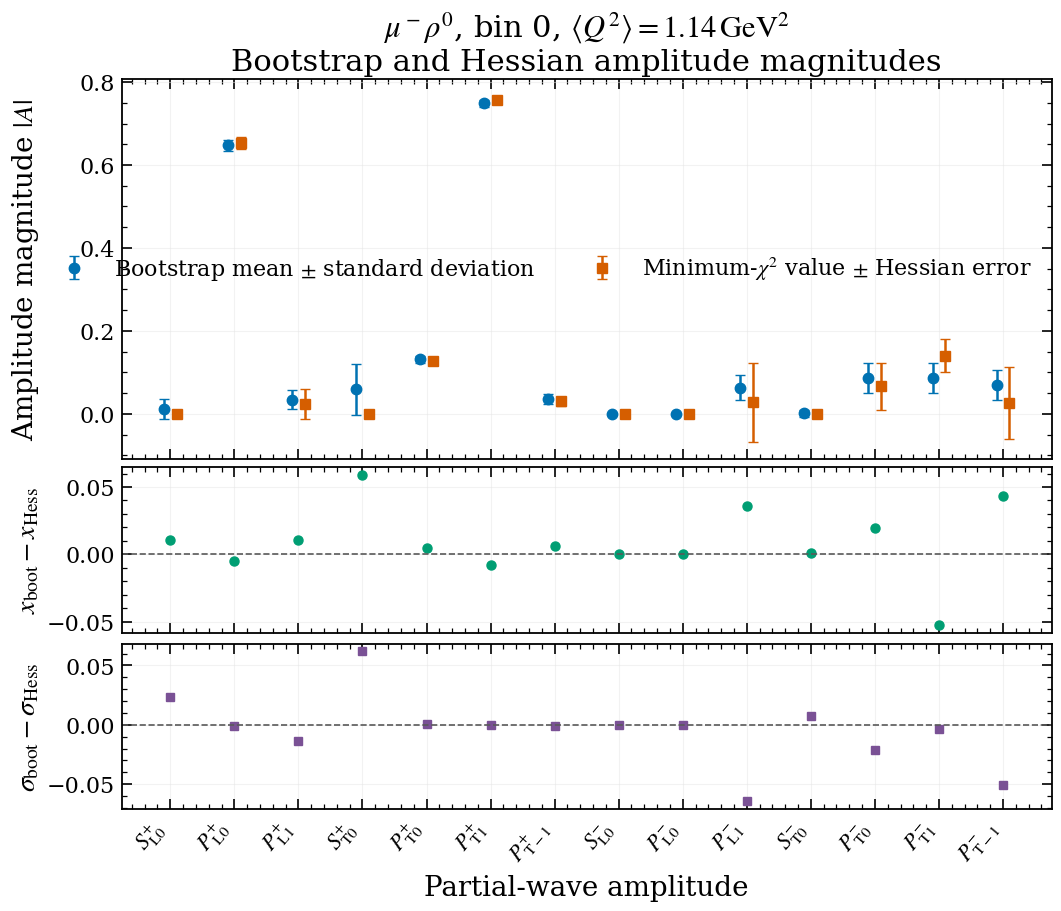

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_0/MuRho_0_bootstrap_vs_hessian_amplitudes.png


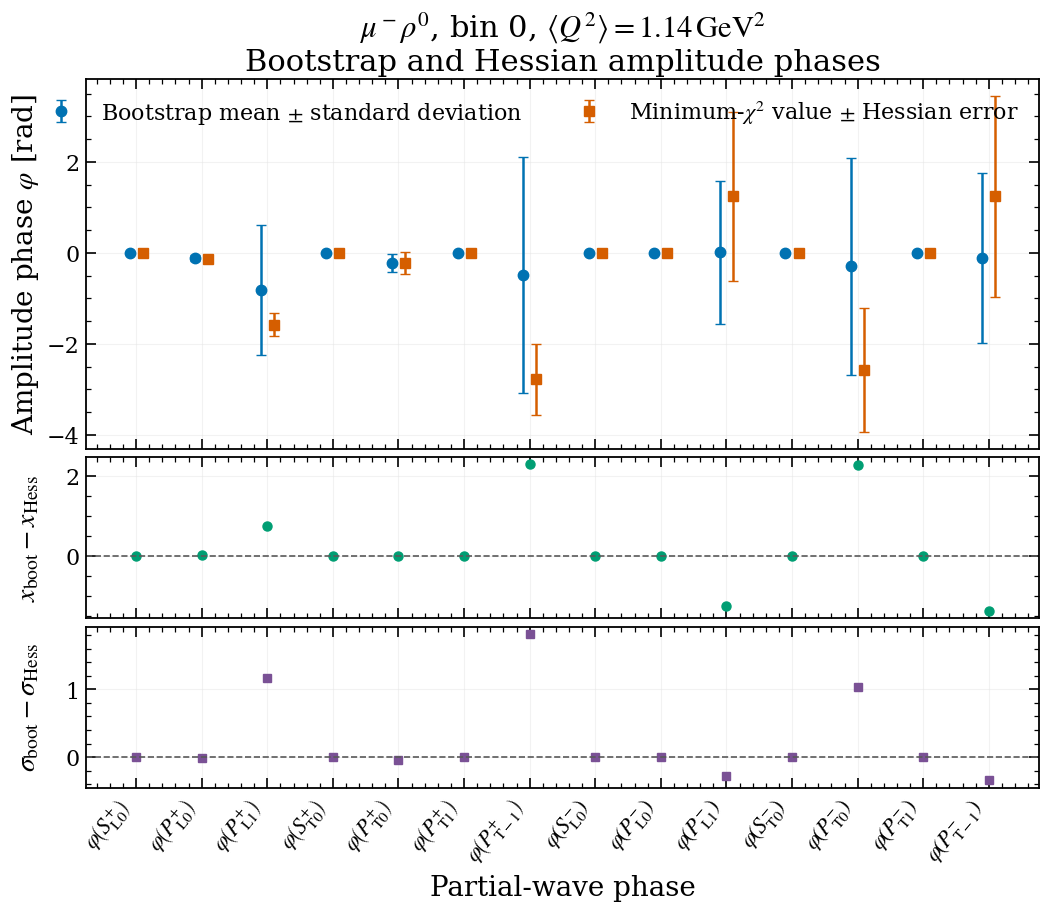

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_0/MuRho_0_bootstrap_vs_hessian_phases.png


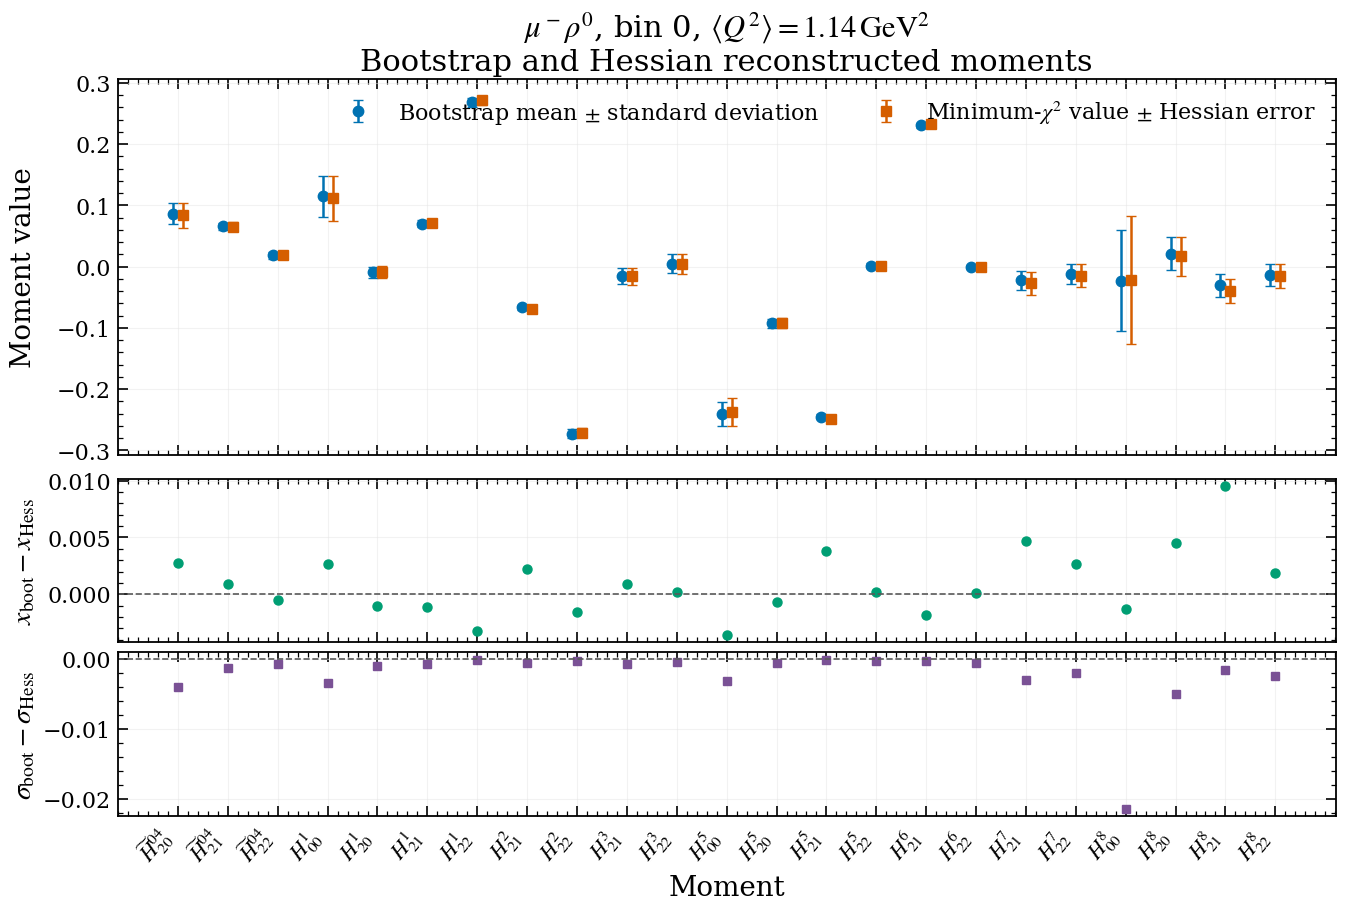

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_0/MuRho_0_bootstrap_vs_hessian_moments.png
MuRho_1: bootstrap 977/1000 replicas; Hessian entry 20265/100000, chi2=7.7701000882


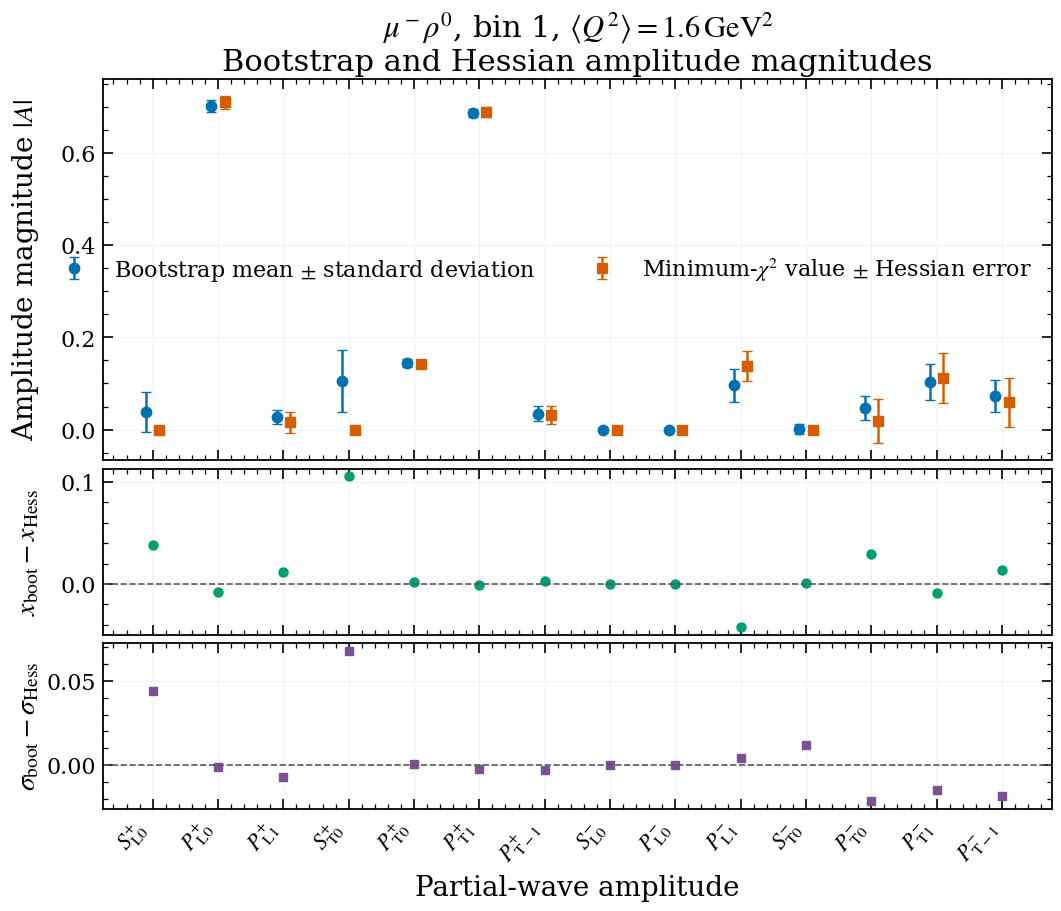

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_1/MuRho_1_bootstrap_vs_hessian_amplitudes.png


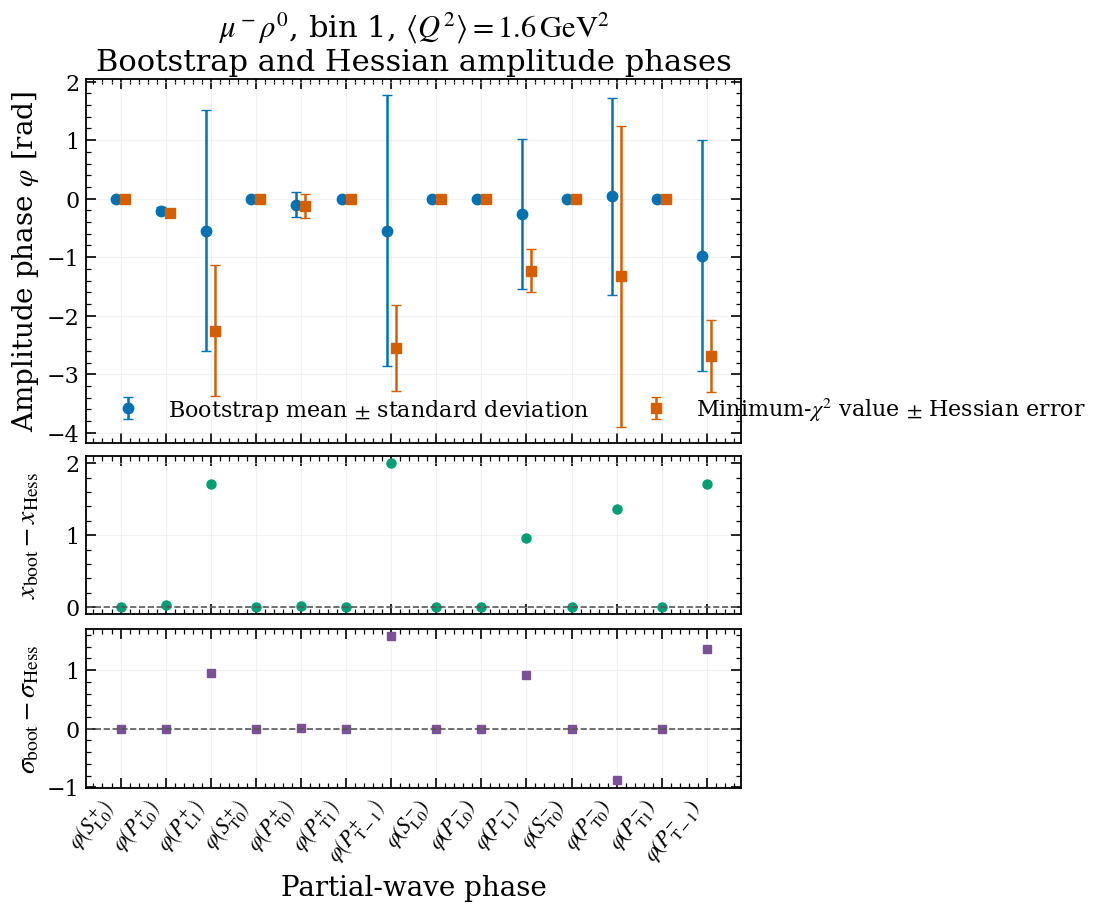

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_1/MuRho_1_bootstrap_vs_hessian_phases.png


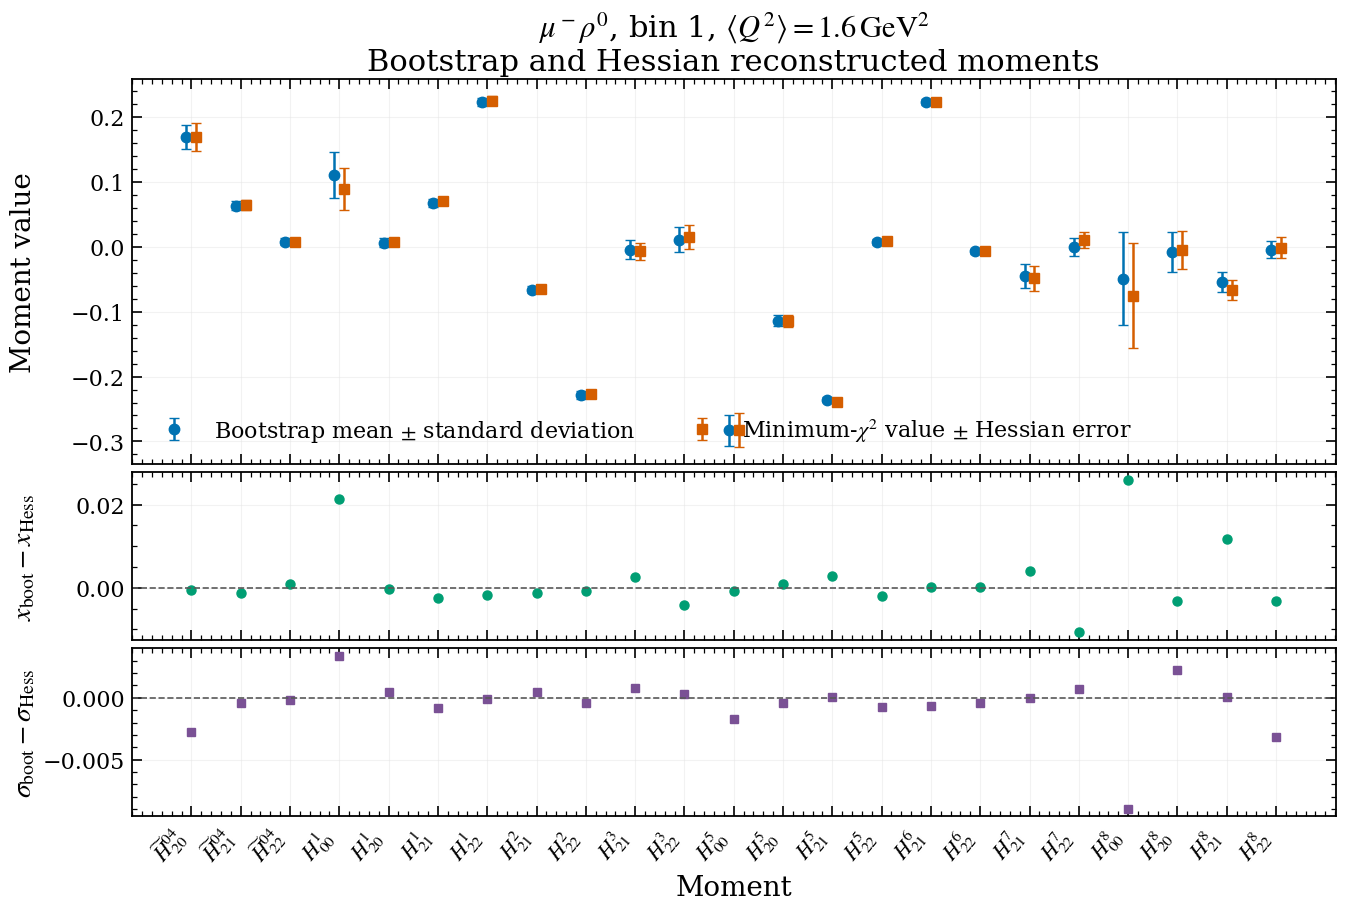

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_1/MuRho_1_bootstrap_vs_hessian_moments.png
MuRho_2: bootstrap 899/1000 replicas; Hessian entry 1749/100000, chi2=14.2237582193


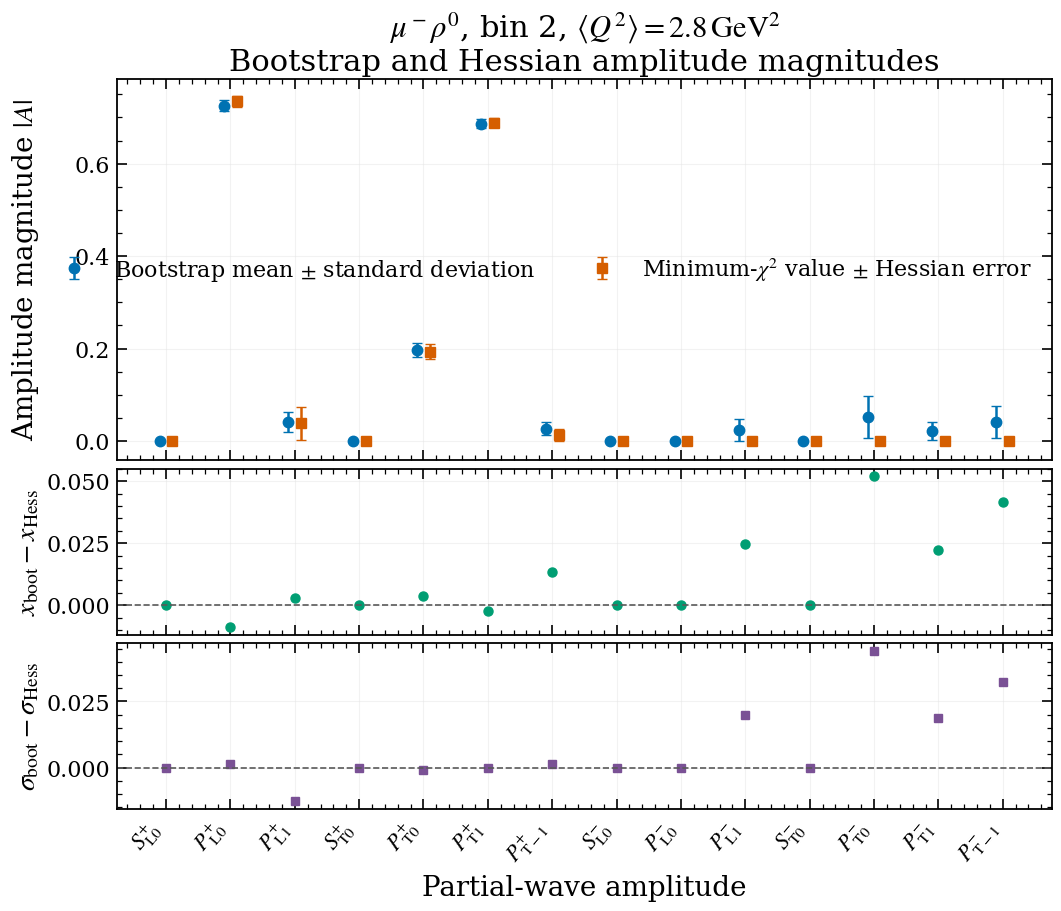

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_2/MuRho_2_bootstrap_vs_hessian_amplitudes.png


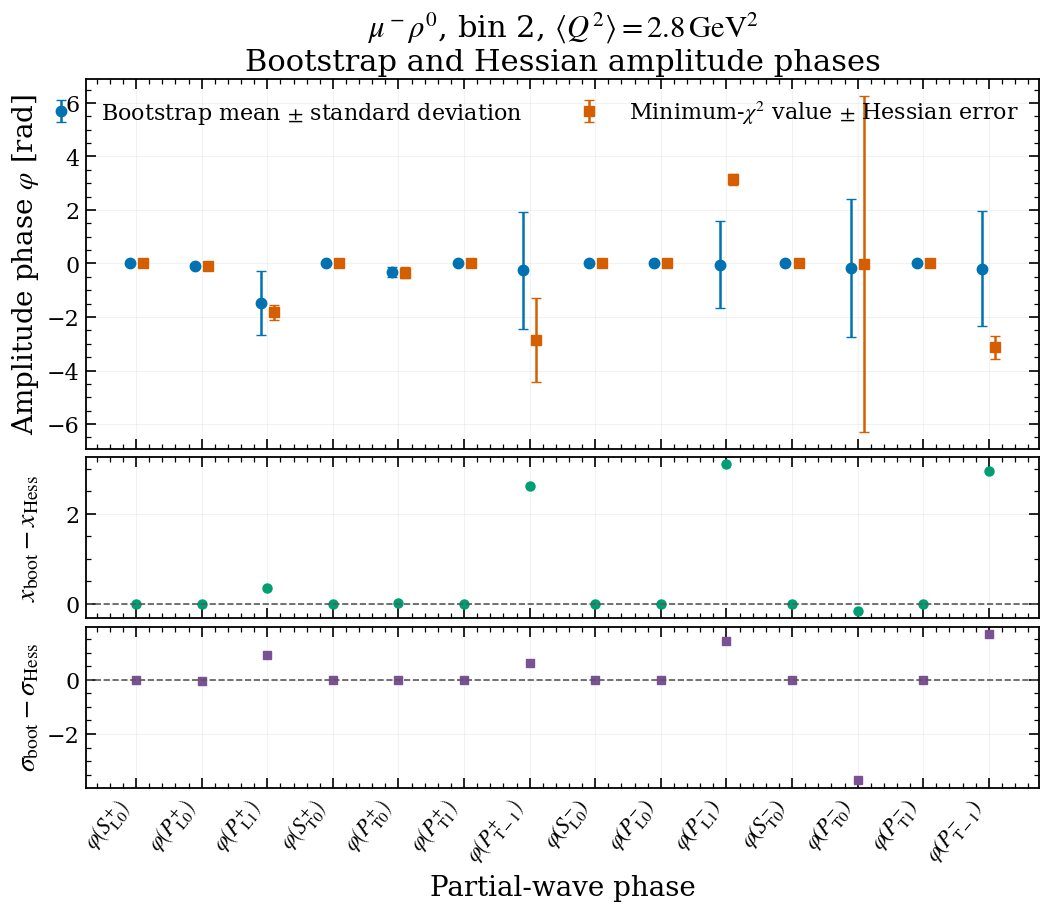

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_2/MuRho_2_bootstrap_vs_hessian_phases.png


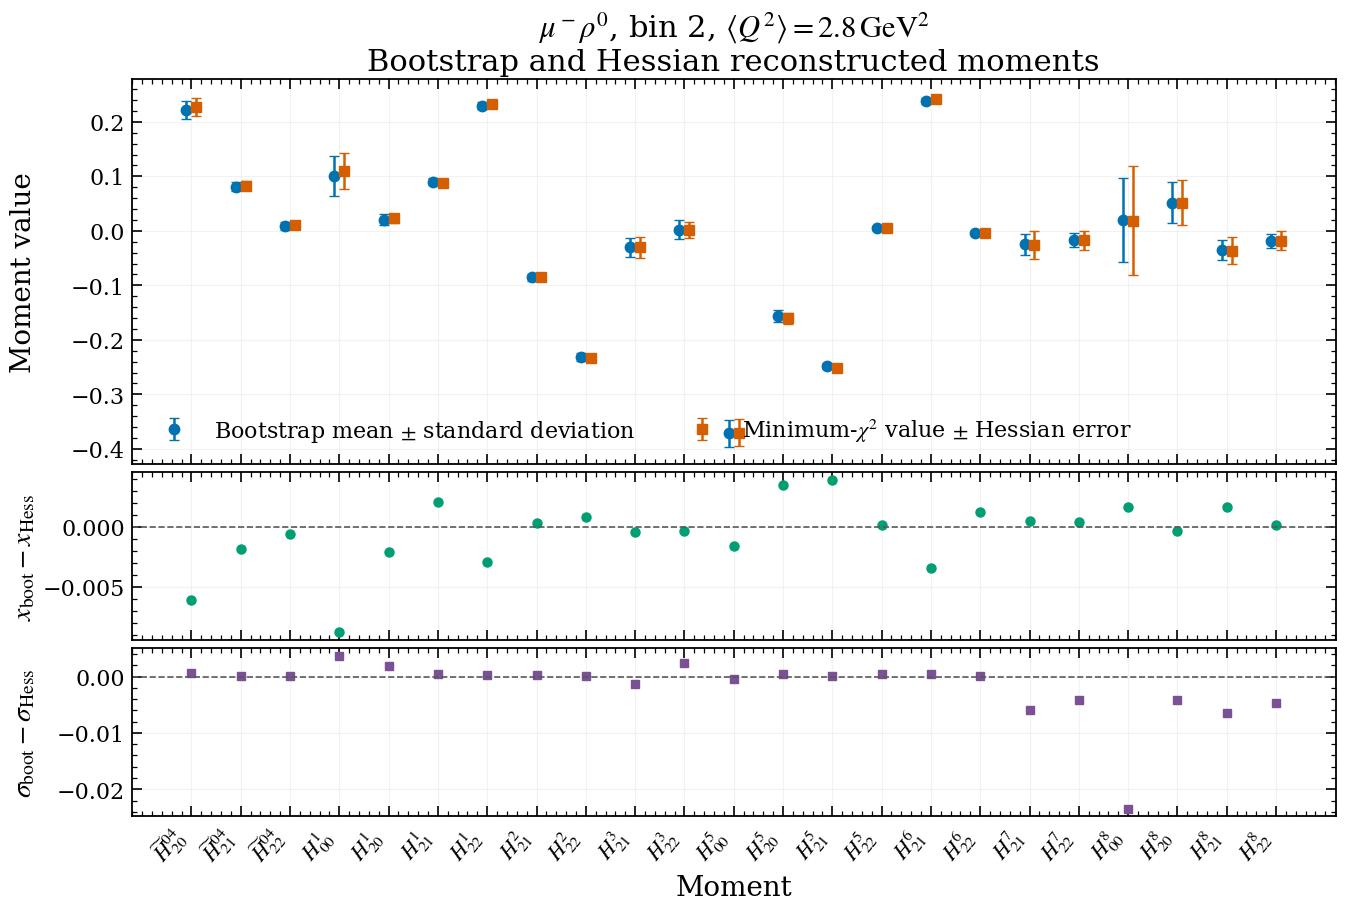

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_2/MuRho_2_bootstrap_vs_hessian_moments.png
MuRho_3: bootstrap 970/1000 replicas; Hessian entry 11986/100000, chi2=7.77501507665


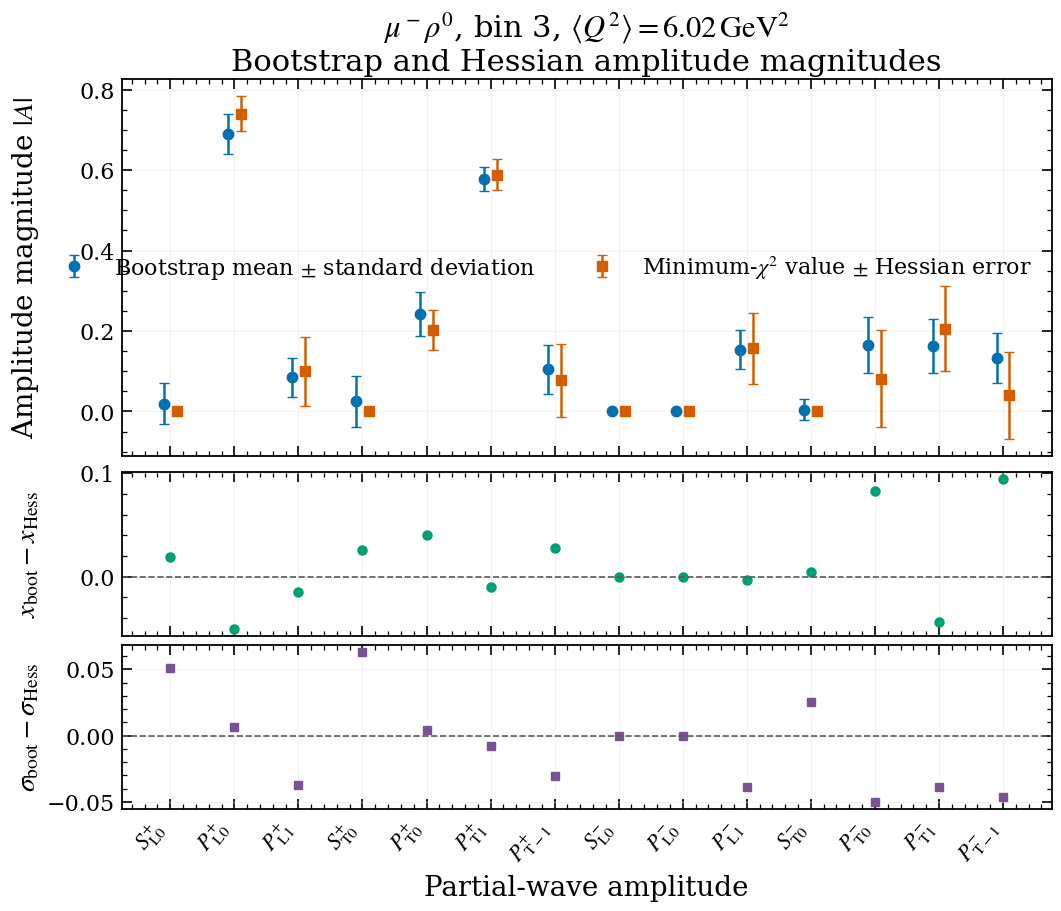

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_3/MuRho_3_bootstrap_vs_hessian_amplitudes.png


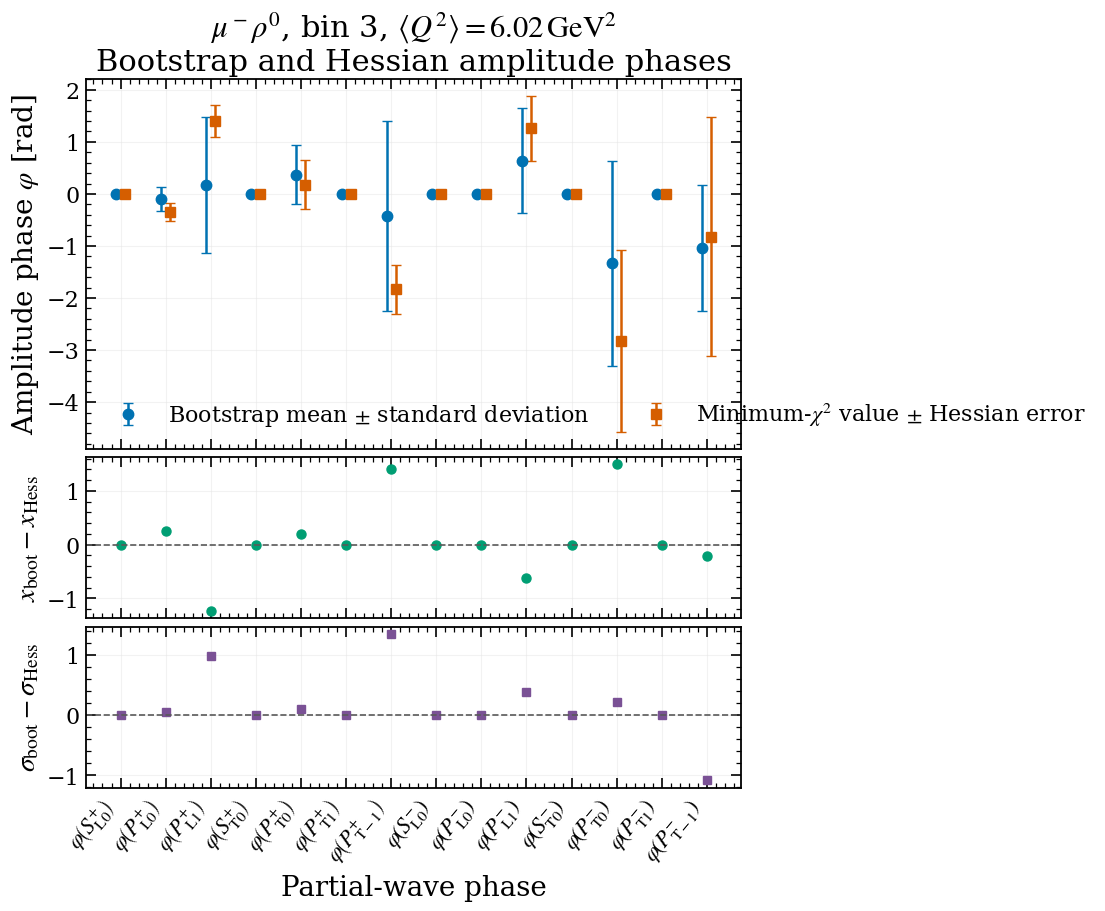

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_3/MuRho_3_bootstrap_vs_hessian_phases.png


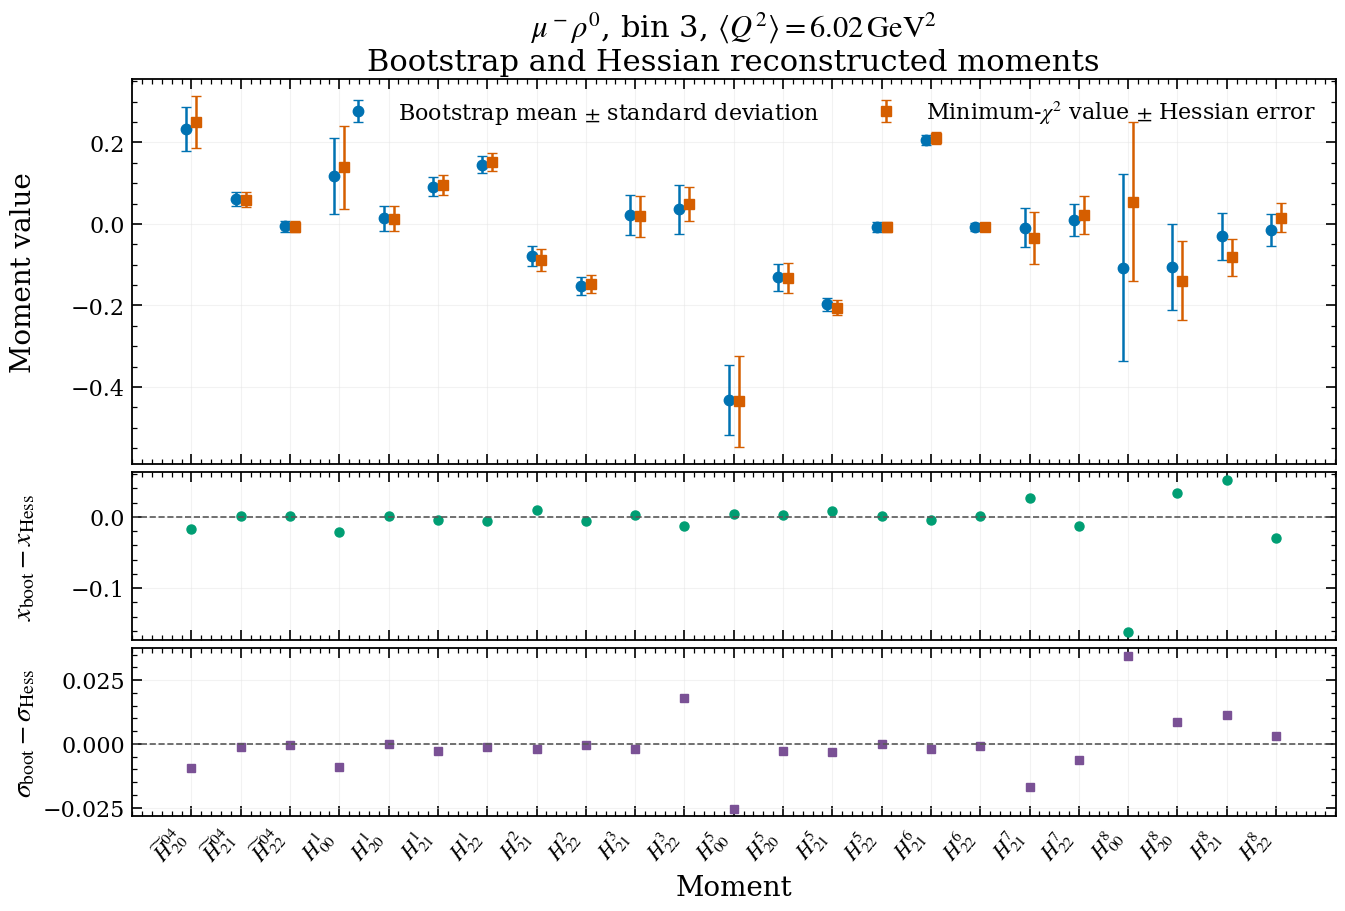

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_3/MuRho_3_bootstrap_vs_hessian_moments.png


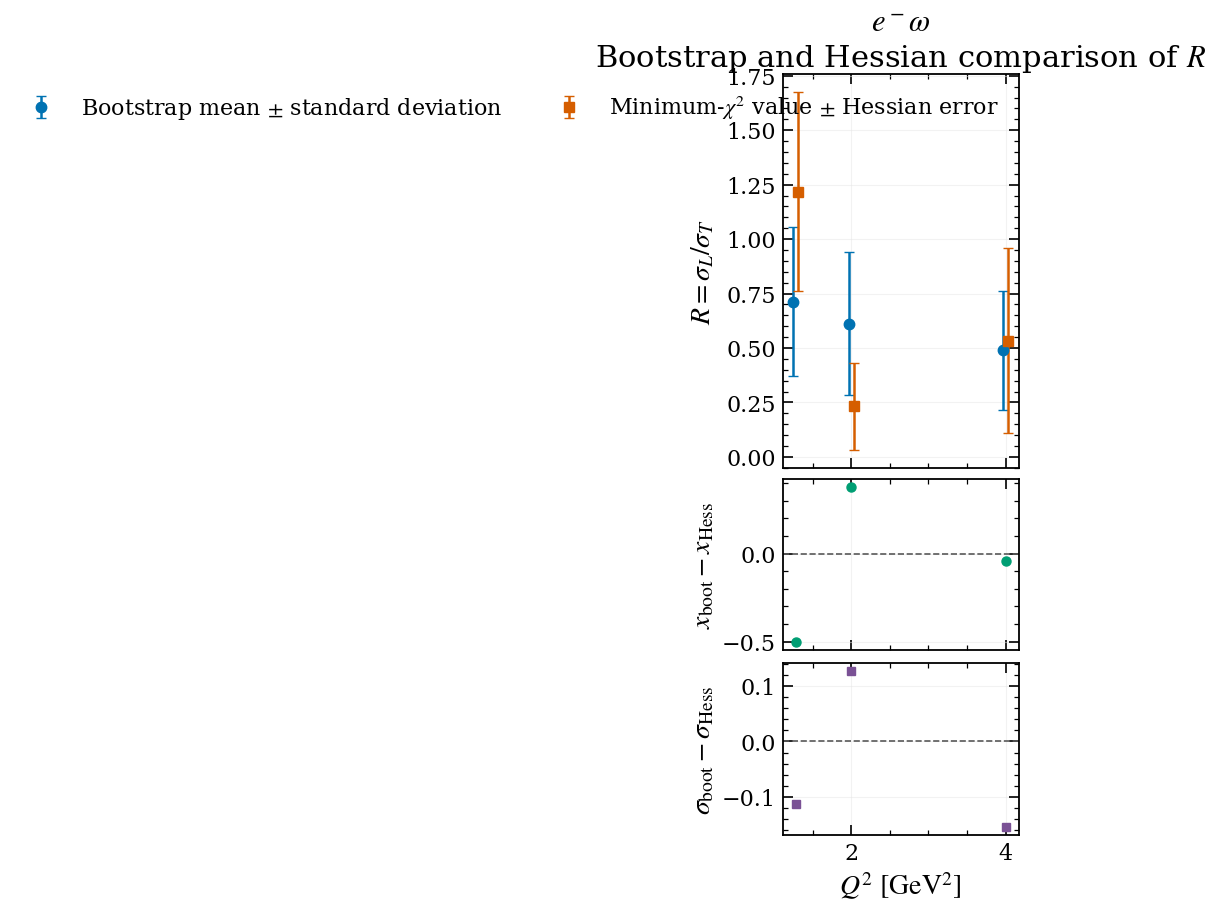

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElOmega_bootstrap_vs_hessian_R.png


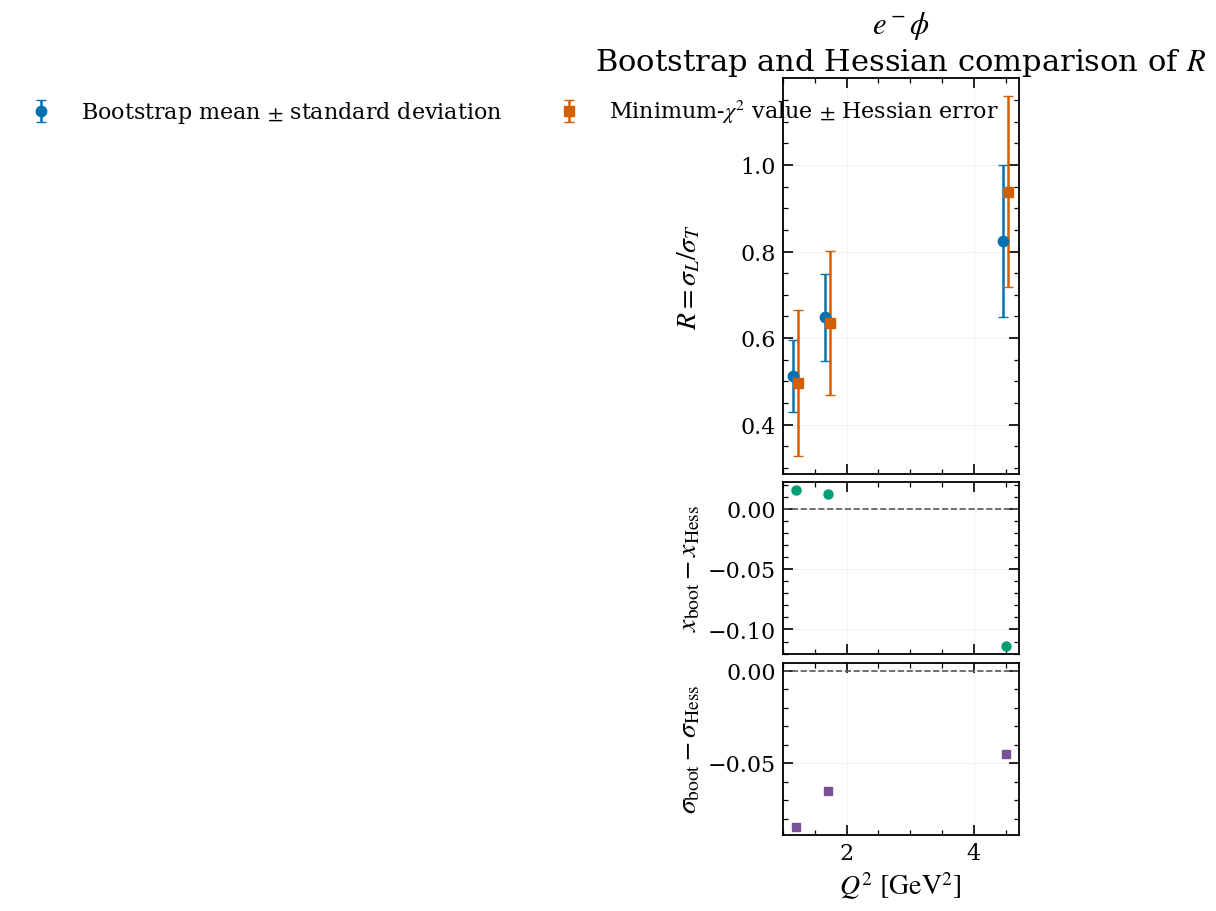

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElPhi_bootstrap_vs_hessian_R.png


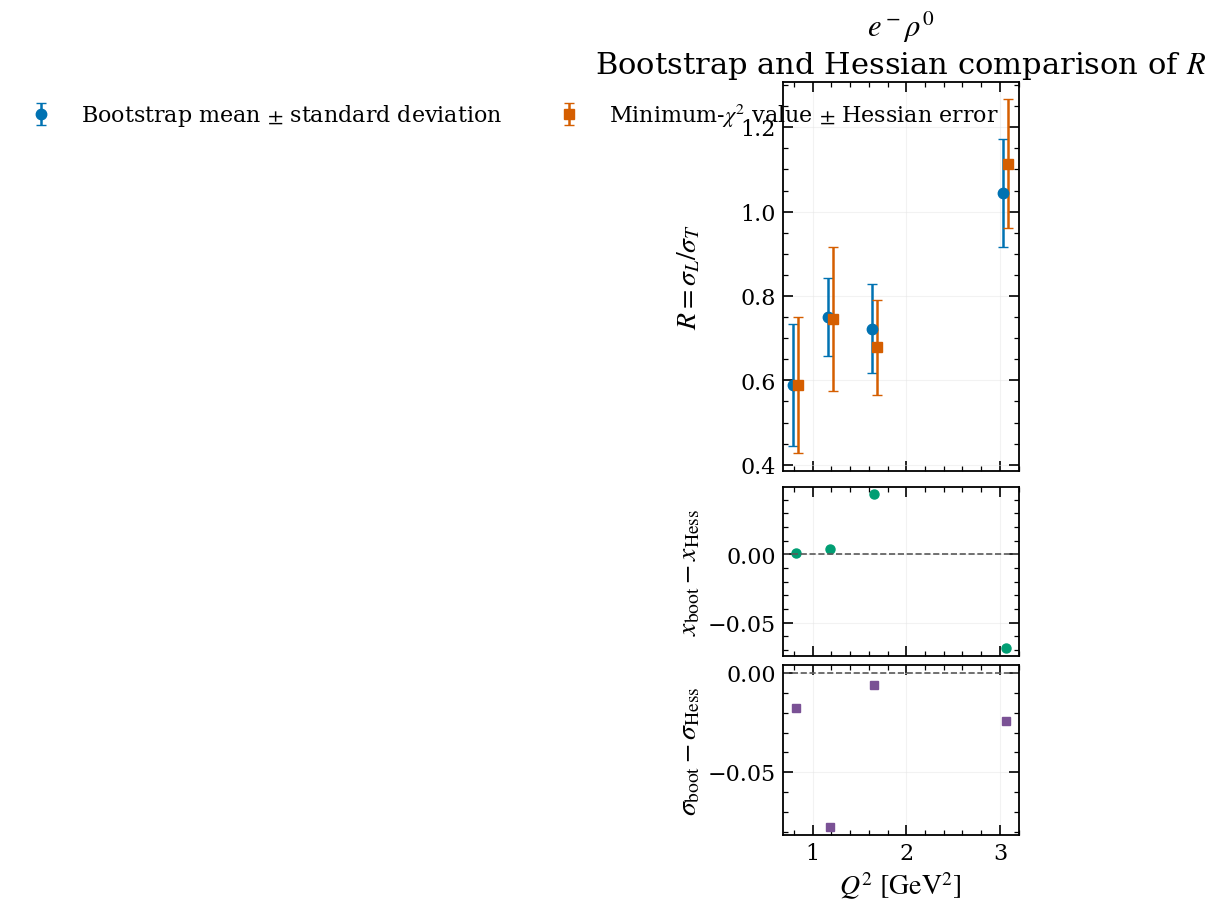

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/ElRho_bootstrap_vs_hessian_R.png


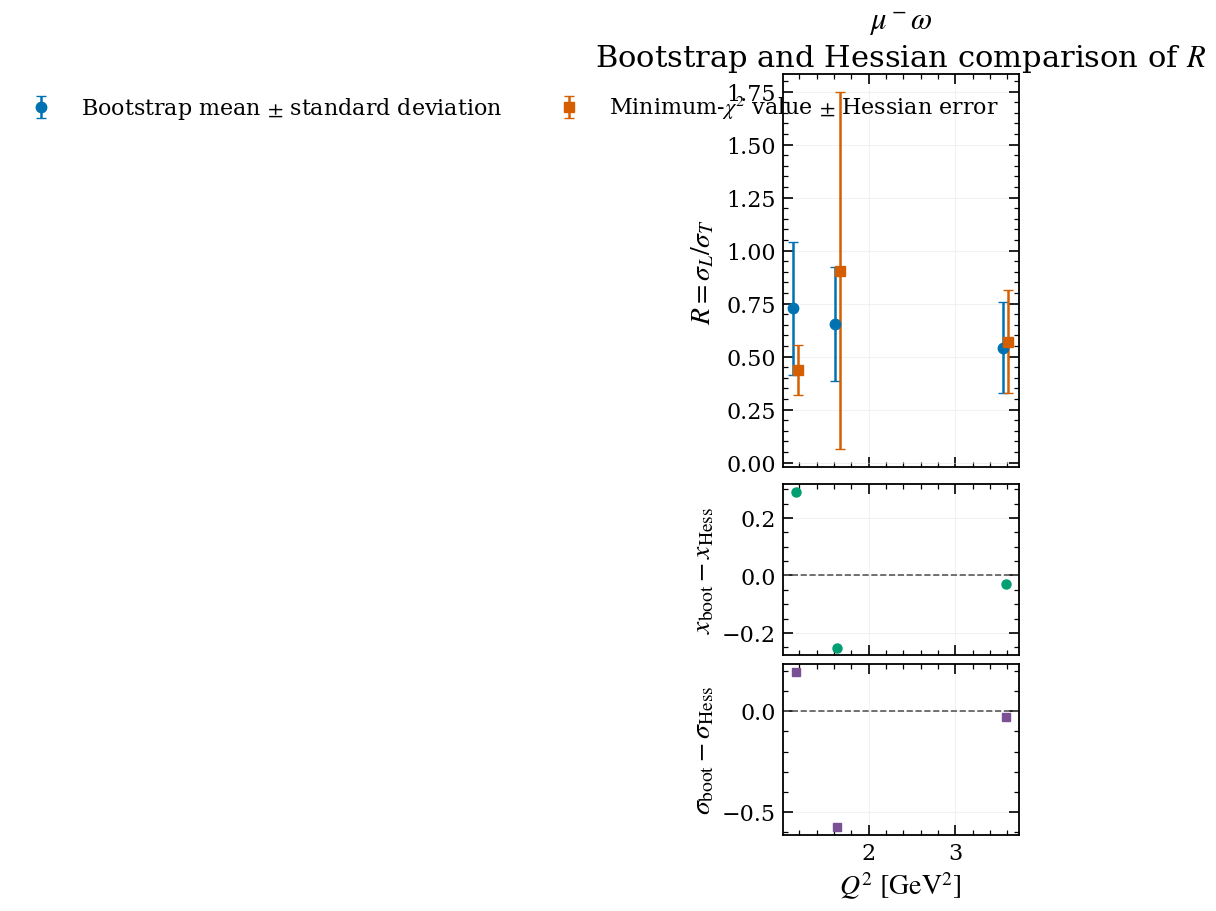

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuOmega_bootstrap_vs_hessian_R.png


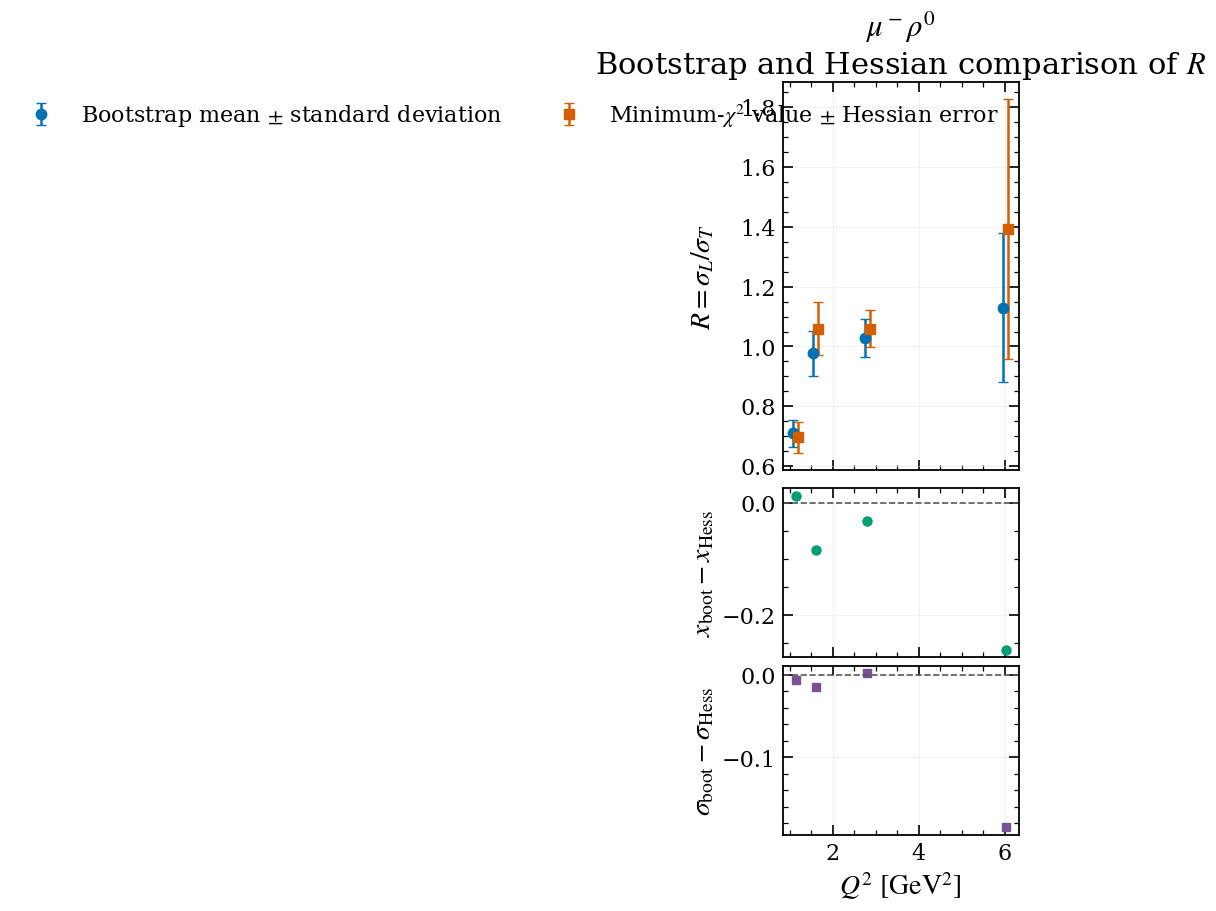

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs/MuRho_bootstrap_vs_hessian_R.png

Wrote only the requested comparison plots beneath /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/bootstrap_vs_hessian_outputs


In [4]:
# -------------------------------------------------------------------------
# Run all matched files: only amplitudes, phases, moments and R are plotted.
# -------------------------------------------------------------------------
R_rows = []

for bootstrap_path, hessian_path in ROOT_FILE_PAIRS:
    metadata = pair_metadata(bootstrap_path, hessian_path)
    key = metadata["key"]
    title = metadata["title"]
    dataset_output = OUTPUT_DIR / key
    dataset_output.mkdir(parents=True, exist_ok=True)

    bootstrap_columns = list_root_branches(bootstrap_path, BOOTSTRAP_TREE)
    hessian_columns = list_root_branches(hessian_path, HESSIAN_TREE)

    amplitude_branches = sorted(
        set(name for name in bootstrap_columns if MAG_RE.match(name))
        & set(name for name in hessian_columns if MAG_RE.match(name))
    )
    phase_branches = sorted(
        set(name for name in bootstrap_columns if PHASE_RE.match(name))
        & set(name for name in hessian_columns if PHASE_RE.match(name))
    )
    bootstrap_moment_branches = [
        name for name in bootstrap_columns if name.startswith("fit_RH")
    ]
    hessian_moment_branches = [
        name for name in hessian_columns if name.startswith("RH")
    ]

    bootstrap_read_columns = amplitude_branches + phase_branches + bootstrap_moment_branches
    bootstrap_read_columns += [
        name for name in ("valid", "status", "chi2", "log_val", "log10_chi2",
                          "R", "H_4_0_0", "H_0_0_0")
        if name in bootstrap_columns
    ]

    hessian_value_columns = amplitude_branches + phase_branches + hessian_moment_branches
    hessian_value_columns += [
        name for name in ("chi2", "log_val", "val", "R", "H_4_0_0", "H_0_0_0")
        if name in hessian_columns
    ]
    hessian_error_columns = [
        name for name in hessian_columns
        if name.startswith(("err__", "err_", "error__"))
        or name.endswith(("_err", "err", "err_"))
        or re.match(r"^[ab](?:phi)?err_[TL]_", name)
    ]
    hessian_read_columns = hessian_value_columns + hessian_error_columns

    bootstrap_frame = read_root_columns(
        bootstrap_path, BOOTSTRAP_TREE, bootstrap_read_columns
    )
    selected_bootstrap = bootstrap_frame.loc[
        bootstrap_quality_mask(bootstrap_frame)
    ].copy()
    if selected_bootstrap.empty:
        raise RuntimeError(f"No valid bootstrap replicas in {bootstrap_path.name}")

    hessian_frame = read_root_columns(
        hessian_path, HESSIAN_TREE, hessian_read_columns
    )
    best_index, hessian_best, objective = select_absolute_lowest(hessian_frame)
    print(
        f"{key}: bootstrap {len(selected_bootstrap)}/{len(bootstrap_frame)} replicas; "
        f"Hessian entry {best_index}/{len(hessian_frame)}, "
        f"{objective}={float(hessian_best[objective]):.12g}"
    )

    amplitude_table = build_parameter_table(
        selected_bootstrap, hessian_best, amplitude_branches, hessian_columns
    )
    make_comparison_figure(
        amplitude_table,
        [wave_label(name) for name in amplitude_table.get("quantity", [])],
        r"Amplitude magnitude $|A|$",
        title + "\nBootstrap and Hessian amplitude magnitudes",
        dataset_output / f"{key}_bootstrap_vs_hessian_amplitudes.png",
        x_label="Partial-wave amplitude",
    )

    phase_table = build_parameter_table(
        selected_bootstrap, hessian_best, phase_branches, hessian_columns
    )
    make_comparison_figure(
        phase_table,
        [phase_label(name) for name in phase_table.get("quantity", [])],
        r"Amplitude phase $\varphi$ [rad]",
        title + "\nBootstrap and Hessian amplitude phases",
        dataset_output / f"{key}_bootstrap_vs_hessian_phases.png",
        wrap_value_difference=WRAP_PHASE_DIFFERENCES,
        x_label="Partial-wave phase",
    )

    moment_table = build_moment_table(
        selected_bootstrap, hessian_best, bootstrap_columns, hessian_columns
    )
    make_comparison_figure(
        moment_table,
        [moment_label(name) for name in moment_table.get("quantity", [])],
        "Moment value",
        title + "\nBootstrap and Hessian reconstructed moments",
        dataset_output / f"{key}_bootstrap_vs_hessian_moments.png",
        x_label="Moment",
    )

    bootstrap_r, bootstrap_r_error = bootstrap_R(selected_bootstrap)
    hessian_r, hessian_r_error = hessian_R(hessian_best, hessian_columns)
    R_rows.append({
        "prefix": metadata["prefix"],
        "bin": metadata["bin"],
        "q2": metadata["q2"],
        "bootstrap_value": bootstrap_r,
        "bootstrap_error": bootstrap_r_error,
        "hessian_value": hessian_r,
        "hessian_error": hessian_r_error,
    })


# R is plotted across all Q2 bins for each reaction rather than as a
# one-point figure for every individual ROOT-file pair.
R_table = pd.DataFrame(R_rows)
for prefix, channel_table in R_table.groupby("prefix", sort=True):
    channel_table = channel_table.sort_values("bin").reset_index(drop=True)
    first_pair = next(
        pair for pair in ROOT_FILE_PAIRS
        if pair_metadata(*pair)["prefix"] == prefix
    )
    metadata = pair_metadata(*first_pair)
    channel_title = metadata["title"].split(", bin")[0]
    q2 = channel_table["q2"].to_numpy(dtype=float)
    if not np.isfinite(q2).all():
        q2 = channel_table["bin"].to_numpy(dtype=float)
        x_label = "Bin index"
    else:
        x_label = r"$Q^2\ [\mathrm{GeV}^2]$"

    make_comparison_figure(
        channel_table,
        labels=None,
        ylabel=r"$R=\sigma_L/\sigma_T$",
        title=channel_title + "\nBootstrap and Hessian comparison of $R$",
        output_path=OUTPUT_DIR / f"{prefix}_bootstrap_vs_hessian_R.png",
        x_values=q2,
        x_label=x_label,
    )

print(f"\nWrote only the requested comparison plots beneath {OUTPUT_DIR.resolve()}")
